In [1]:
# ============================================
# Section 1: Import Libraries
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
# ============================================
# Section 2: Load Datasets
# ============================================

# Load Theme 1 dataset
theme1 = pd.read_csv('/content/Theme1_Features.csv')

# Load Theme 2 dataset
theme2 = pd.read_csv('/content/Theme2_Features.csv')

# Load combined Theme 1 + Theme 2 dataset
theme12 = pd.read_csv('/content/Theme1 and Theme2 Features.csv')

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [3]:
# ============================================
# Section 3: Dataset Overview
# ============================================

print("=" * 70)
print("THEME 1 DATASET OVERVIEW")
print("=" * 70)

print(f"\nDataset Shape: {theme1.shape}")

print("\nColumn Names:")
print(theme1.columns.tolist())

print("\nFirst 5 Records:")
display(theme1.head())

print("\nDataset Information:")
theme1.info()



print("\n\n" + "=" * 70)
print("THEME 2 DATASET OVERVIEW")
print("=" * 70)

print(f"\nDataset Shape: {theme2.shape}")

print("\nColumn Names:")
print(theme2.columns.tolist())

print("\nFirst 5 Records:")
display(theme2.head())

print("\nDataset Information:")
theme2.info()



print("\n\n" + "=" * 70)
print("THEME 1 + THEME 2 DATASET OVERVIEW")
print("=" * 70)

print(f"\nDataset Shape: {theme12.shape}")

print("\nColumn Names:")
print(theme12.columns.tolist())

print("\nFirst 5 Records:")
display(theme12.head())

print("\nDataset Information:")
theme12.info()

THEME 1 DATASET OVERVIEW

Dataset Shape: (5410, 15)

Column Names:
['Provider', 'Total_Inpatient_Claims', 'Total_Outpatient_Claims', 'Total_Claims', 'Unique_Beneficiaries', 'Avg_Inpatient_Reimbursement', 'Avg_Outpatient_Reimbursement', 'Total_Inpatient_Reimbursement', 'Total_Outpatient_Reimbursement', 'Avg_Claim_Duration', 'Avg_Length_of_Stay', 'Inpatient_Outpatient_Ratio', 'Number_of_States_Served', 'Number_of_Counties_Served', 'PotentialFraud']

First 5 Records:


,Provider,Total_Inpatient_Claims,Total_Outpatient_Claims,Total_Claims,Unique_Beneficiaries,Avg_Inpatient_Reimbursement,Avg_Outpatient_Reimbursement,Total_Inpatient_Reimbursement,Total_Outpatient_Reimbursement,Avg_Claim_Duration,Avg_Length_of_Stay,Inpatient_Outpatient_Ratio,Number_of_States_Served,Number_of_Counties_Served,PotentialFraud
0,PRV51001,5.0,20.0,25.0,24,19400.000000,382.000000,97000.0,7640.0,5.000000,5.000000,0.250000,1,7,No
1,PRV51003,62.0,70.0,132.0,117,9241.935484,466.714286,573000.0,32670.0,5.161290,5.161290,0.885714,3,23,Yes
2,PRV51004,0.0,149.0,149.0,138,0.000000,350.134228,0.0,52170.0,0.000000,0.000000,0.000000,9,28,No
3,PRV51005,0.0,1165.0,1165.0,495,0.000000,241.124464,0.0,280910.0,0.000000,0.000000,0.000000,4,26,Yes
4,PRV51007,3.0,69.0,72.0,58,6333.333333,213.188406,19000.0,14710.0,5.333333,5.333333,0.043478,2,6,No



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5410 entries, 0 to 5409
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Provider                        5410 non-null   object 
 1   Total_Inpatient_Claims          5410 non-null   float64
 2   Total_Outpatient_Claims         5410 non-null   float64
 3   Total_Claims                    5410 non-null   float64
 4   Unique_Beneficiaries            5410 non-null   int64  
 5   Avg_Inpatient_Reimbursement     5410 non-null   float64
 6   Avg_Outpatient_Reimbursement    5410 non-null   float64
 7   Total_Inpatient_Reimbursement   5410 non-null   float64
 8   Total_Outpatient_Reimbursement  5410 non-null   float64
 9   Avg_Claim_Duration              5410 non-null   float64
 10  Avg_Length_of_Stay              5410 non-null   float64
 11  Inpatient_Outpatient_Ratio      5410 non-null   float64
 12  Number_of_St

,Provider,AveragePatientAge,PercentageMalePatients,PercentageFemalePatients,AveragePartACoverage,AveragePartBCoverage,AlzheimerPatientPercentage,HeartFailurePatientPercentage,KidneyDiseasePatientPercentage,CancerPatientPercentage,...,AverageAnnualOutpatientReimbursement,AverageAnnualInpatientDeductible,AverageAnnualOutpatientDeductible,AverageDeductiblePaidPerClaim,NumberOfUniqueDiagnosisCodes,NumberOfUniqueProcedureCodes,NumberOfUniqueAttendingPhysicians,NumberOfUniqueOperatingPhysicians,NumberOfUniqueOtherPhysicians,PotentialFraud
0,PRV51001,78.208333,37.500000,62.500000,12.000000,12.000000,58.333333,75.000000,70.833333,20.833333,...,2537.500000,890.000000,474.916667,213.600000,72.0,3.0,14,5.0,8.0,No
1,PRV51003,69.051282,41.880342,58.119658,11.794872,11.854701,37.606838,59.829060,44.444444,8.547009,...,2490.598291,822.632479,664.529915,502.166667,365.0,39.0,44,7.0,22.0,Yes
2,PRV51004,72.557971,32.608696,67.391304,11.855072,11.956522,43.478261,59.420290,34.057971,11.594203,...,2095.144928,454.144928,600.869565,2.080537,267.0,0.0,38,19.0,26.0,No
3,PRV51005,70.070707,42.020202,57.979798,11.830303,11.886869,33.333333,53.131313,35.959596,11.919192,...,1798.808081,398.698990,475.965657,3.175966,1294.0,0.0,6,6.0,4.0,Yes
4,PRV51007,68.017241,46.551724,53.448276,11.793103,11.793103,36.206897,51.724138,29.310345,10.344828,...,1497.241379,423.517241,430.689655,45.333333,165.0,1.0,10,5.0,7.0,No



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5410 entries, 0 to 5409
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Provider                              5410 non-null   object 
 1   AveragePatientAge                     5410 non-null   float64
 2   PercentageMalePatients                5410 non-null   float64
 3   PercentageFemalePatients              5410 non-null   float64
 4   AveragePartACoverage                  5410 non-null   float64
 5   AveragePartBCoverage                  5410 non-null   float64
 6   AlzheimerPatientPercentage            5410 non-null   float64
 7   HeartFailurePatientPercentage         5410 non-null   float64
 8   KidneyDiseasePatientPercentage        5410 non-null   float64
 9   CancerPatientPercentage               5410 non-null   float64
 10  COPDPatientPercentage                 5410 non-null   float64


,Provider,Total_Inpatient_Claims,Total_Outpatient_Claims,Total_Claims,Unique_Beneficiaries,Avg_Inpatient_Reimbursement,Avg_Outpatient_Reimbursement,Total_Inpatient_Reimbursement,Total_Outpatient_Reimbursement,Avg_Claim_Duration,...,AverageAnnualOutpatientReimbursement,AverageAnnualInpatientDeductible,AverageAnnualOutpatientDeductible,AverageDeductiblePaidPerClaim,NumberOfUniqueDiagnosisCodes,NumberOfUniqueProcedureCodes,NumberOfUniqueAttendingPhysicians,NumberOfUniqueOperatingPhysicians,NumberOfUniqueOtherPhysicians,PotentialFraud
0,PRV51001,5.0,20.0,25.0,24,19400.000000,382.000000,97000.0,7640.0,5.000000,...,2537.500000,890.000000,474.916667,213.600000,72.0,3.0,14,5.0,8.0,No
1,PRV51003,62.0,70.0,132.0,117,9241.935484,466.714286,573000.0,32670.0,5.161290,...,2490.598291,822.632479,664.529915,502.166667,365.0,39.0,44,7.0,22.0,Yes
2,PRV51004,0.0,149.0,149.0,138,0.000000,350.134228,0.0,52170.0,0.000000,...,2095.144928,454.144928,600.869565,2.080537,267.0,0.0,38,19.0,26.0,No
3,PRV51005,0.0,1165.0,1165.0,495,0.000000,241.124464,0.0,280910.0,0.000000,...,1798.808081,398.698990,475.965657,3.175966,1294.0,0.0,6,6.0,4.0,Yes
4,PRV51007,3.0,69.0,72.0,58,6333.333333,213.188406,19000.0,14710.0,5.333333,...,1497.241379,423.517241,430.689655,45.333333,165.0,1.0,10,5.0,7.0,No



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5410 entries, 0 to 5409
Data columns (total 41 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Provider                              5410 non-null   object 
 1   Total_Inpatient_Claims                5410 non-null   float64
 2   Total_Outpatient_Claims               5410 non-null   float64
 3   Total_Claims                          5410 non-null   float64
 4   Unique_Beneficiaries                  5410 non-null   int64  
 5   Avg_Inpatient_Reimbursement           5410 non-null   float64
 6   Avg_Outpatient_Reimbursement          5410 non-null   float64
 7   Total_Inpatient_Reimbursement         5410 non-null   float64
 8   Total_Outpatient_Reimbursement        5410 non-null   float64
 9   Avg_Claim_Duration                    5410 non-null   float64
 10  Avg_Length_of_Stay                    5410 non-null   float64


In [4]:
# ============================================
# Section 4: Data Quality Assessment
# ============================================

datasets = {
    "Theme 1": theme1,
    "Theme 2": theme2,
    "Theme 1 + Theme 2": theme12
}

for name, df in datasets.items():

    print("=" * 70)
    print(f"{name} Data Quality Assessment")
    print("=" * 70)

    # Missing values
    print("\n1. Missing Values")
    print(df.isnull().sum())

    # Duplicate rows
    print("\n2. Duplicate Rows")
    print(df.duplicated().sum())

    # Duplicate Provider IDs
    print("\n3. Duplicate Provider IDs")
    print(df["Provider"].duplicated().sum())

    # Target variable distribution
    print("\n4. Target Variable")
    print(df["PotentialFraud"].value_counts())

    # Data types
    print("\n5. Data Types")
    print(df.dtypes)

    print("\n")

Theme 1 Data Quality Assessment

1. Missing Values
Provider                          0
Total_Inpatient_Claims            0
Total_Outpatient_Claims           0
Total_Claims                      0
Unique_Beneficiaries              0
Avg_Inpatient_Reimbursement       0
Avg_Outpatient_Reimbursement      0
Total_Inpatient_Reimbursement     0
Total_Outpatient_Reimbursement    0
Avg_Claim_Duration                0
Avg_Length_of_Stay                0
Inpatient_Outpatient_Ratio        0
Number_of_States_Served           0
Number_of_Counties_Served         0
PotentialFraud                    0
dtype: int64

2. Duplicate Rows
0

3. Duplicate Provider IDs
0

4. Target Variable
PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64

5. Data Types
Provider                           object
Total_Inpatient_Claims            float64
Total_Outpatient_Claims           float64
Total_Claims                      float64
Unique_Beneficiaries                int64
Avg_Inpatient_Reimbursement       fl

In [5]:
# ============================================
# Section 5: Target Variable Analysis
# ============================================

# Count the number of fraudulent and non-fraudulent providers
fraud_counts = theme12['PotentialFraud'].value_counts()

print("PotentialFraud Distribution:")
print(fraud_counts)

# Calculate percentage distribution
fraud_percentage = theme12['PotentialFraud'].value_counts(normalize=True) * 100

print("\nPercentage Distribution:")
print(fraud_percentage.round(2))

PotentialFraud Distribution:
PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64

Percentage Distribution:
PotentialFraud
No     90.65
Yes     9.35
Name: proportion, dtype: float64


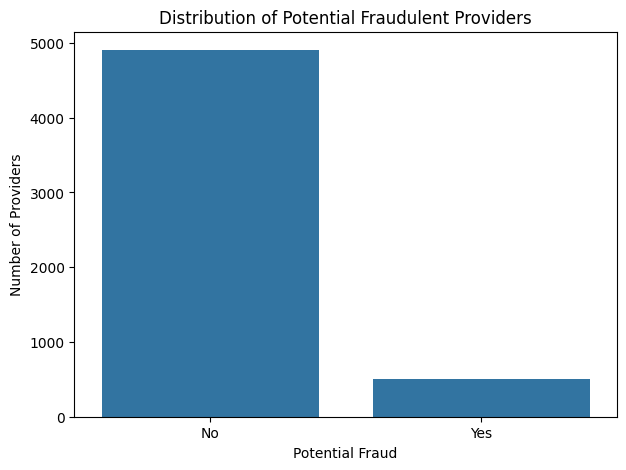

In [6]:
# Visualize the distribution of the target variable
plt.figure(figsize=(7, 5))

sns.countplot(data=theme12, x='PotentialFraud')

plt.title('Distribution of Potential Fraudulent Providers')
plt.xlabel('Potential Fraud')
plt.ylabel('Number of Providers')

plt.show()

In [7]:
# ============================================
# Section 6: Summary Statistics
# ============================================

# Display descriptive statistics for Theme 1 engineered features
print("=" * 70)
print("THEME 1 SUMMARY STATISTICS")
print("=" * 70)

display(
    theme1.drop(columns=['Provider', 'PotentialFraud']).describe().T
)

THEME 1 SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max
Total_Inpatient_Claims,5410.0,7.481331,23.704217,0.0,0.00000,0.000000,5.000000,516.0
Total_Outpatient_Claims,5410.0,95.700000,266.520526,0.0,7.00000,27.000000,77.000000,8240.0
Total_Claims,5410.0,103.181331,272.456989,1.0,10.00000,31.000000,87.000000,8240.0
Unique_Beneficiaries,5410.0,67.153420,142.748729,1.0,8.00000,25.000000,65.000000,2857.0
Avg_Inpatient_Reimbursement,5410.0,3947.382878,5909.941519,0.0,0.00000,0.000000,8333.333333,57000.0
Avg_Outpatient_Reimbursement,5410.0,281.988333,1316.248082,0.0,159.53125,254.926042,323.333333,95580.0
Total_Inpatient_Reimbursement,5410.0,75470.798521,242013.779821,0.0,0.00000,0.000000,48000.000000,5580870.0
Total_Outpatient_Reimbursement,5410.0,27402.240296,76178.298977,0.0,1602.50000,7400.000000,22615.000000,2321890.0
Avg_Claim_Duration,5410.0,2.188905,3.246215,0.0,0.00000,0.000000,4.666667,35.0
Avg_Length_of_Stay,5410.0,2.190740,3.249546,0.0,0.00000,0.000000,4.666667,35.0


In [8]:
# Display descriptive statistics for Theme 2 engineered features
print("=" * 70)
print("THEME 2 SUMMARY STATISTICS")
print("=" * 70)

display(
    theme2.drop(columns=['Provider', 'PotentialFraud']).describe().T
)

THEME 2 SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max
AveragePatientAge,5410.0,73.302950,4.560740,34.0,71.487947,73.387041,75.155397,100.000000
PercentageMalePatients,5410.0,42.107918,17.610706,0.0,35.294118,42.137830,50.000000,100.000000
PercentageFemalePatients,5410.0,57.892082,17.610706,0.0,50.000000,57.862170,64.705882,100.000000
AveragePartACoverage,5410.0,11.917535,0.390096,0.0,11.992188,12.000000,12.000000,12.000000
AveragePartBCoverage,5410.0,11.927564,0.296366,0.0,11.954868,12.000000,12.000000,12.000000
AlzheimerPatientPercentage,5410.0,39.383173,17.744824,0.0,32.352941,38.888889,46.506528,100.000000
HeartFailurePatientPercentage,5410.0,58.016425,17.991019,0.0,50.000000,57.692308,65.811005,100.000000
KidneyDiseasePatientPercentage,5410.0,40.559216,18.658108,0.0,32.894737,39.260188,48.387097,100.000000
CancerPatientPercentage,5410.0,14.870106,12.893411,0.0,8.695652,13.852714,18.600924,100.000000
COPDPatientPercentage,5410.0,31.119846,17.179619,0.0,23.809524,29.729730,37.500000,100.000000


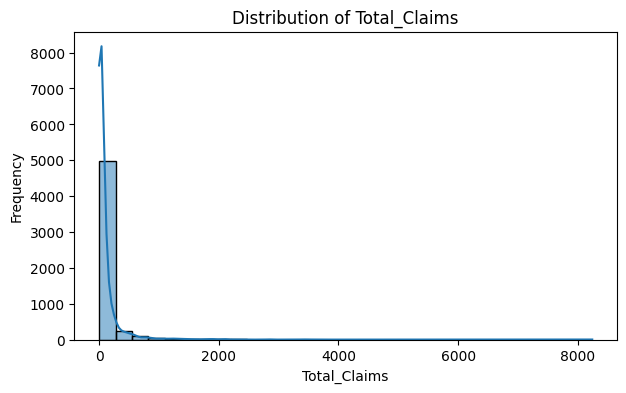

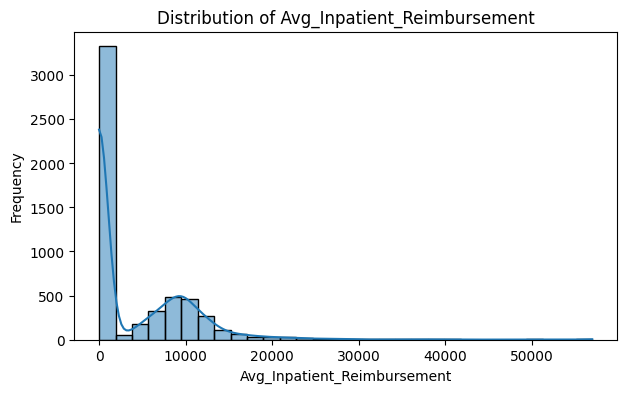

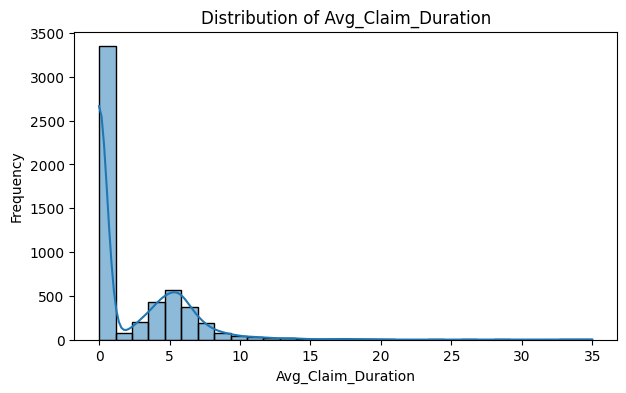

In [9]:
# ============================================
# Section 6.3: Distribution of Selected Features
# ============================================

# Visualize the distribution of selected Theme 1 features
theme1_selected = [
    'Total_Claims',
    'Avg_Inpatient_Reimbursement',
    'Avg_Claim_Duration'
]

for feature in theme1_selected:

    plt.figure(figsize=(7, 4))

    sns.histplot(theme1[feature], bins=30, kde=True)

    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    plt.show()

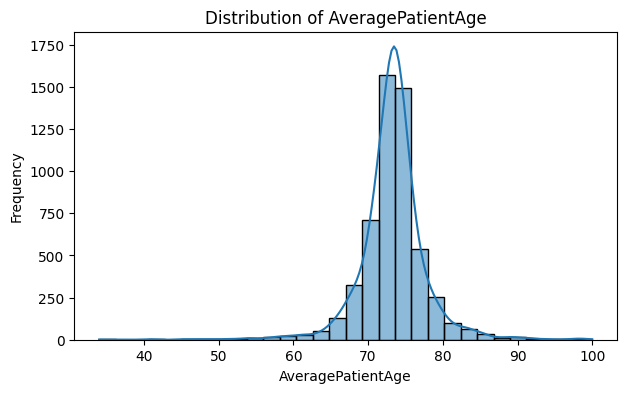

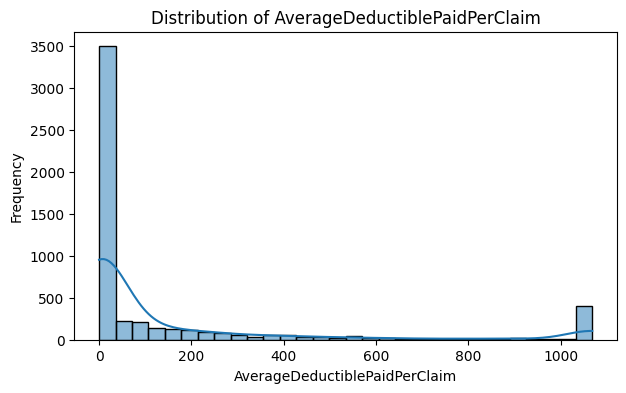

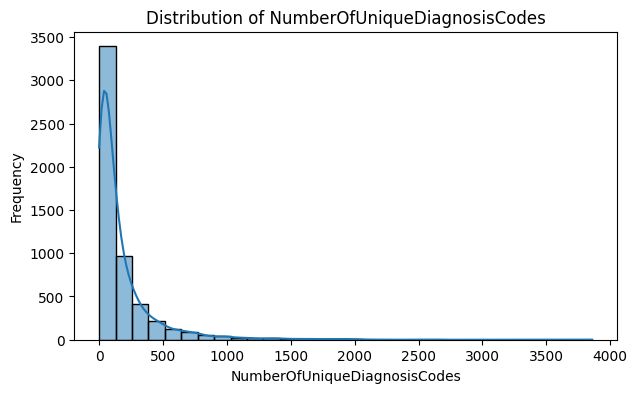

In [10]:
# ============================================
# Section 6.4: Theme 2 Feature Distributions
# ============================================

# Visualize the distribution of selected Theme 2 features
theme2_selected = [
    'AveragePatientAge',
    'AverageDeductiblePaidPerClaim',
    'NumberOfUniqueDiagnosisCodes'
]

for feature in theme2_selected:

    plt.figure(figsize=(7, 4))

    sns.histplot(theme2[feature], bins=30, kde=True)

    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    plt.show()

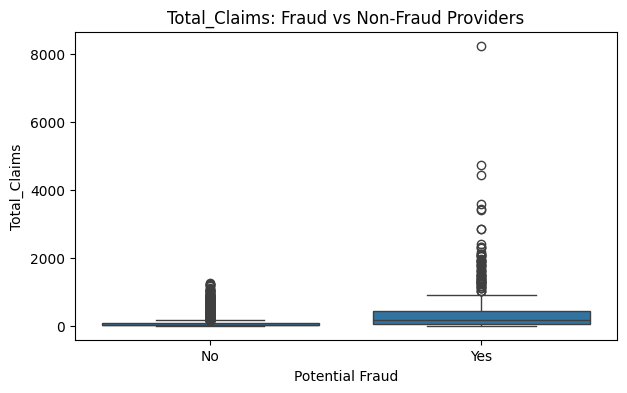

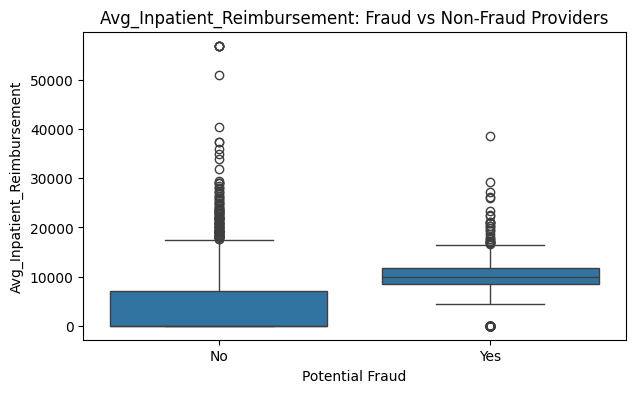

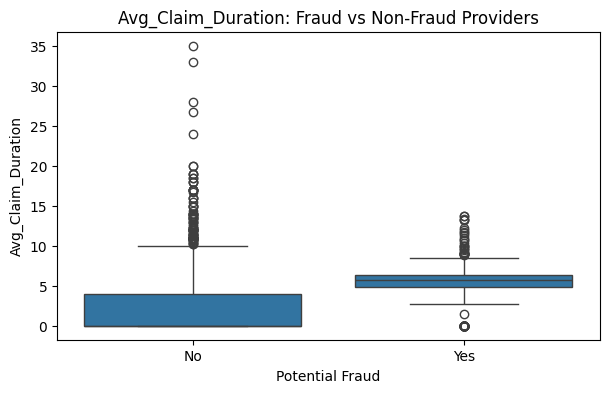

In [11]:
# ============================================
# Section 7.1: Theme 1 Fraud vs Non-Fraud
# ============================================

# Compare selected Theme 1 features between fraud and non-fraud providers
theme1_selected = [
    'Total_Claims',
    'Avg_Inpatient_Reimbursement',
    'Avg_Claim_Duration'
]

for feature in theme1_selected:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=theme1,
        x='PotentialFraud',
        y=feature
    )

    plt.title(f'{feature}: Fraud vs Non-Fraud Providers')
    plt.xlabel('Potential Fraud')
    plt.ylabel(feature)

    plt.show()

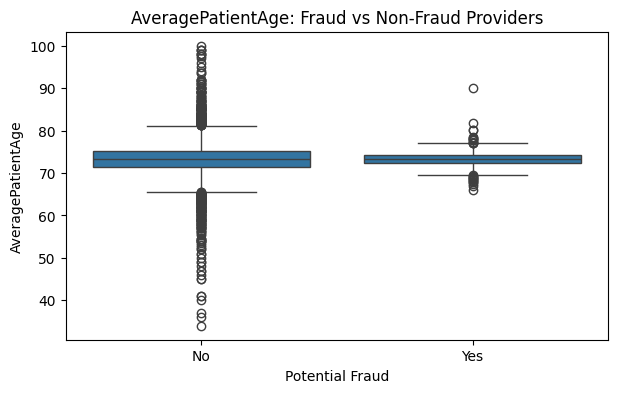

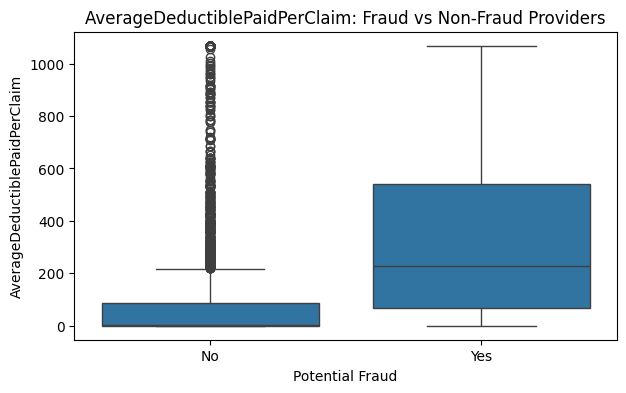

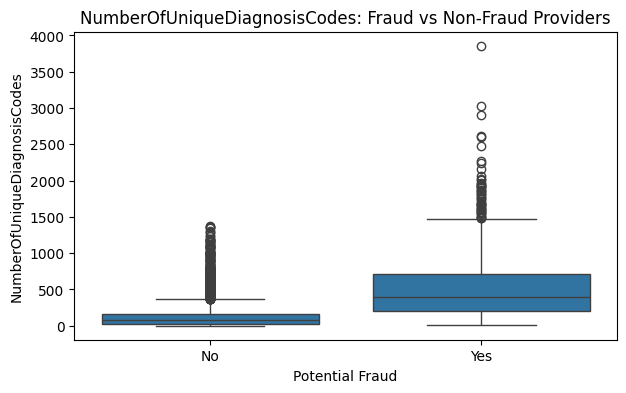

In [12]:
# ============================================
# Section 7.2: Theme 2 Fraud vs Non-Fraud
# ============================================

# Compare selected Theme 2 features between fraud and non-fraud providers
theme2_selected = [
    'AveragePatientAge',
    'AverageDeductiblePaidPerClaim',
    'NumberOfUniqueDiagnosisCodes'
]

for feature in theme2_selected:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=theme2,
        x='PotentialFraud',
        y=feature
    )

    plt.title(f'{feature}: Fraud vs Non-Fraud Providers')
    plt.xlabel('Potential Fraud')
    plt.ylabel(feature)

    plt.show()

In [13]:
# ============================================
# Section 8.1: Prepare Data for Correlation
# ============================================

# Create copies of the datasets for correlation analysis
theme1_corr = theme1.copy()
theme2_corr = theme2.copy()
theme12_corr = theme12.copy()

# Encode PotentialFraud as 0 = No and 1 = Yes
theme1_corr['PotentialFraud'] = theme1_corr['PotentialFraud'].map({'No': 0, 'Yes': 1})
theme2_corr['PotentialFraud'] = theme2_corr['PotentialFraud'].map({'No': 0, 'Yes': 1})
theme12_corr['PotentialFraud'] = theme12_corr['PotentialFraud'].map({'No': 0, 'Yes': 1})

# Verify the encoding
print("Theme 1:")
print(theme1_corr['PotentialFraud'].value_counts())

print("\nTheme 2:")
print(theme2_corr['PotentialFraud'].value_counts())

print("\nTheme 1 + Theme 2:")
print(theme12_corr['PotentialFraud'].value_counts())

Theme 1:
PotentialFraud
0    4904
1     506
Name: count, dtype: int64

Theme 2:
PotentialFraud
0    4904
1     506
Name: count, dtype: int64

Theme 1 + Theme 2:
PotentialFraud
0    4904
1     506
Name: count, dtype: int64


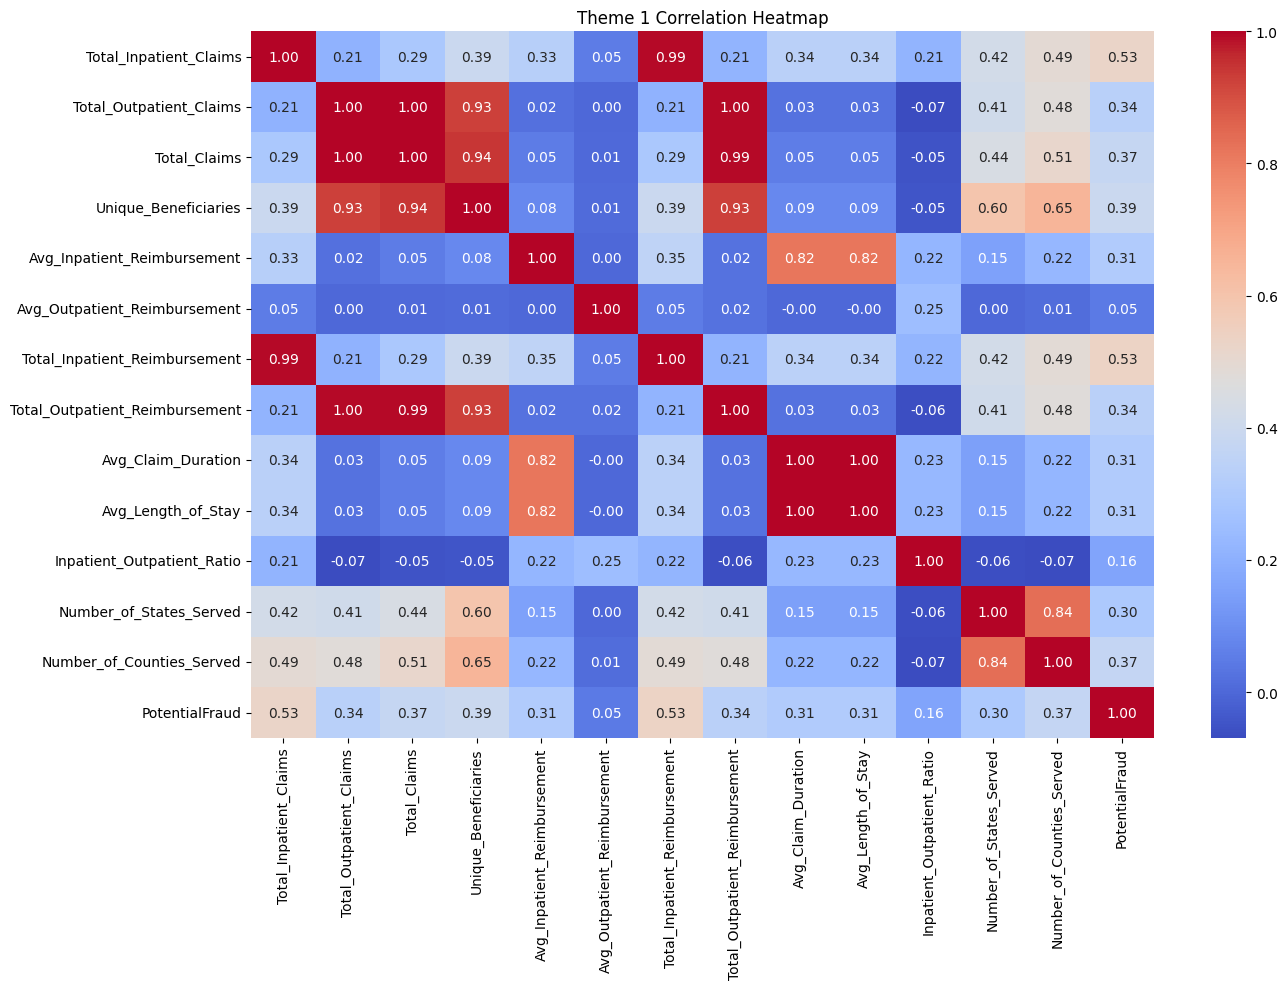

In [14]:
# ============================================
# Section 8.2: Theme 1 Correlation Analysis
# ============================================

# Calculate correlations between Theme 1 features
theme1_correlation = theme1_corr.drop(columns=['Provider']).corr()

# Visualize the correlation matrix
plt.figure(figsize=(14, 10))

sns.heatmap(
    theme1_correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Theme 1 Correlation Heatmap')
plt.tight_layout()
plt.show()

In [15]:
# Rank Theme 1 features by correlation with PotentialFraud
theme1_fraud_correlation = (
    theme1_correlation['PotentialFraud']
    .drop('PotentialFraud')
    .sort_values(ascending=False)
)

print("Theme 1 Feature Correlation with PotentialFraud:")
display(theme1_fraud_correlation)

Theme 1 Feature Correlation with PotentialFraud:


,PotentialFraud
Total_Inpatient_Reimbursement,0.532795
Total_Inpatient_Claims,0.525393
Unique_Beneficiaries,0.393531
Total_Claims,0.374197
Number_of_Counties_Served,0.372852
Total_Outpatient_Reimbursement,0.337756
Total_Outpatient_Claims,0.335803
Avg_Claim_Duration,0.309239
Avg_Length_of_Stay,0.308969
Avg_Inpatient_Reimbursement,0.307556


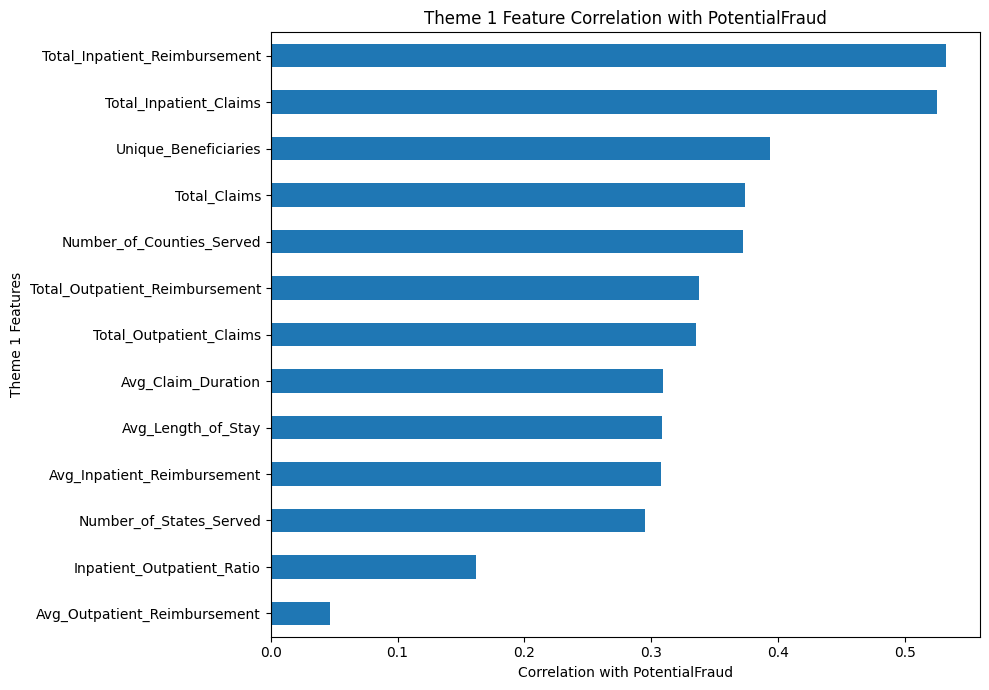

In [16]:
# Visualize Theme 1 feature correlations with PotentialFraud
plt.figure(figsize=(10, 7))

theme1_fraud_correlation.sort_values().plot(
    kind='barh'
)

plt.title('Theme 1 Feature Correlation with PotentialFraud')
plt.xlabel('Correlation with PotentialFraud')
plt.ylabel('Theme 1 Features')

plt.tight_layout()
plt.show()

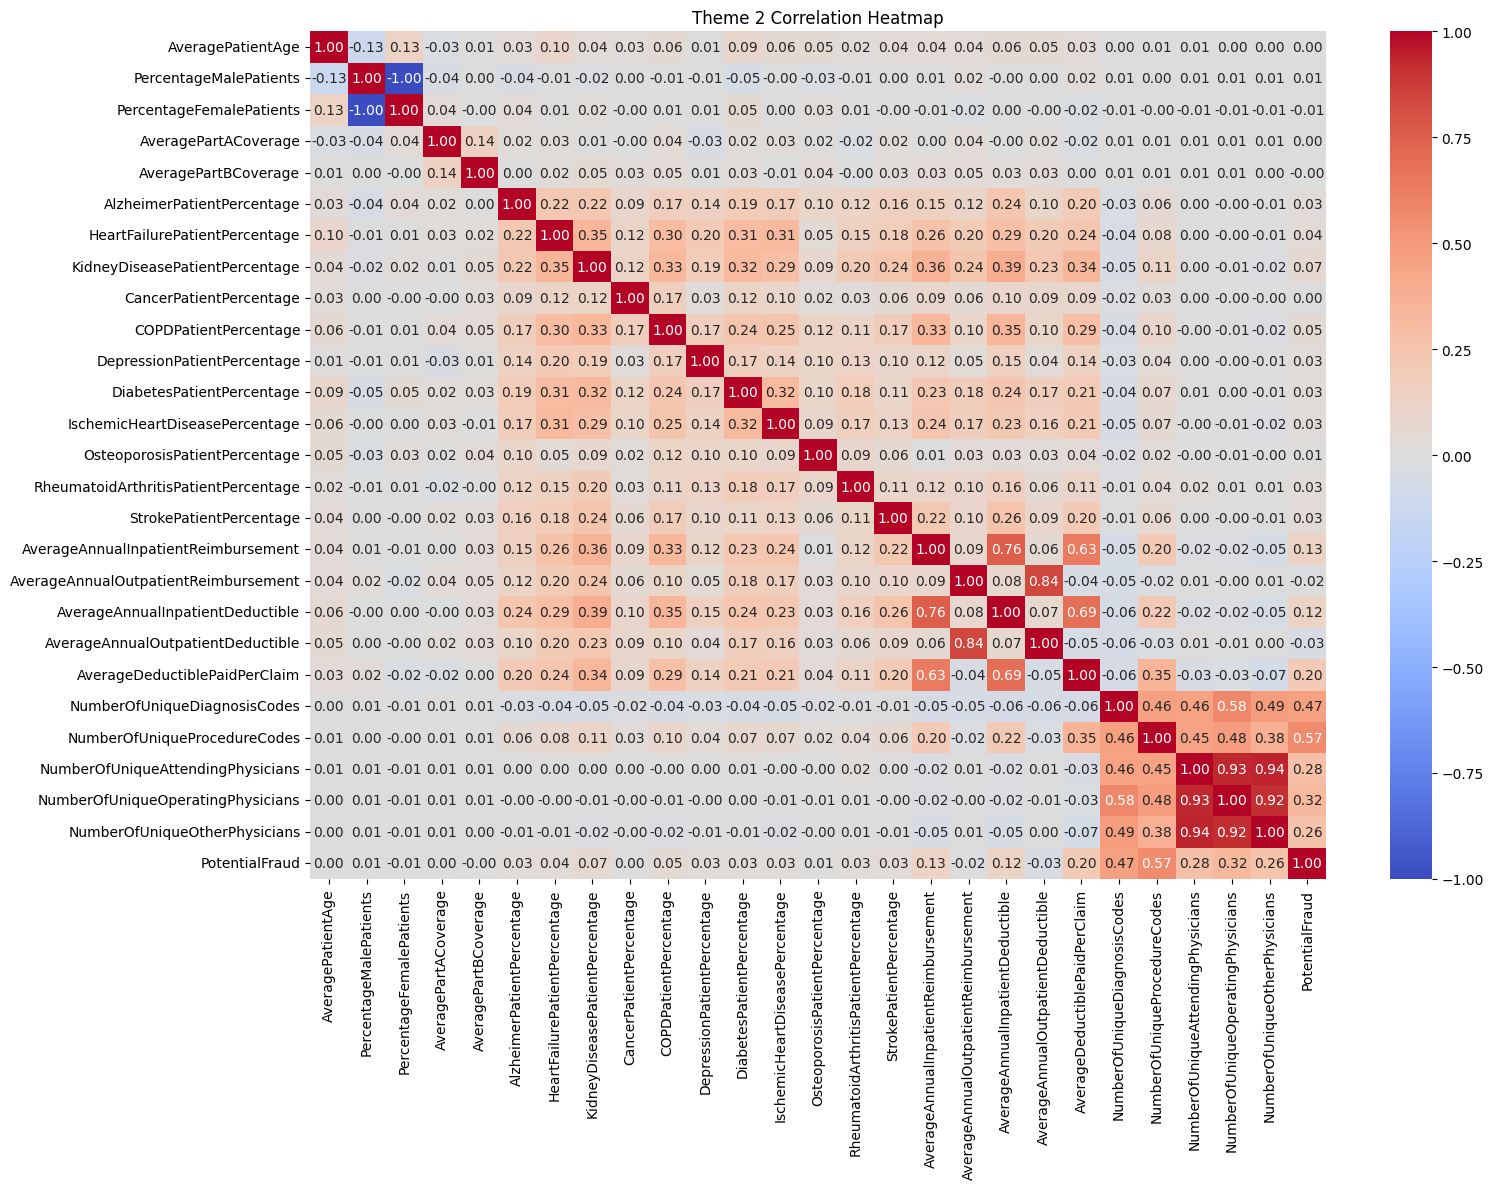

In [17]:
# ============================================
# Section 8.3: Theme 2 Correlation Analysis
# ============================================

# Calculate correlations between Theme 2 features
theme2_correlation = theme2_corr.drop(columns=['Provider']).corr()

# --------------------------------------------
# 1. Correlation Heatmap
# --------------------------------------------

plt.figure(figsize=(16, 12))

sns.heatmap(
    theme2_correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Theme 2 Correlation Heatmap')
plt.tight_layout()
plt.show()


In [18]:
# --------------------------------------------
# 2. Rank Theme 2 Features Against PotentialFraud
# --------------------------------------------

theme2_fraud_correlation = (
    theme2_correlation['PotentialFraud']
    .drop('PotentialFraud')
    .sort_values(ascending=False)
)

print("Theme 2 Feature Correlation with PotentialFraud:")
display(theme2_fraud_correlation)

Theme 2 Feature Correlation with PotentialFraud:


,PotentialFraud
NumberOfUniqueProcedureCodes,0.566664
NumberOfUniqueDiagnosisCodes,0.467892
NumberOfUniqueOperatingPhysicians,0.324408
NumberOfUniqueAttendingPhysicians,0.276772
NumberOfUniqueOtherPhysicians,0.261695
AverageDeductiblePaidPerClaim,0.204640
AverageAnnualInpatientReimbursement,0.127398
AverageAnnualInpatientDeductible,0.119897
KidneyDiseasePatientPercentage,0.065479
COPDPatientPercentage,0.049616


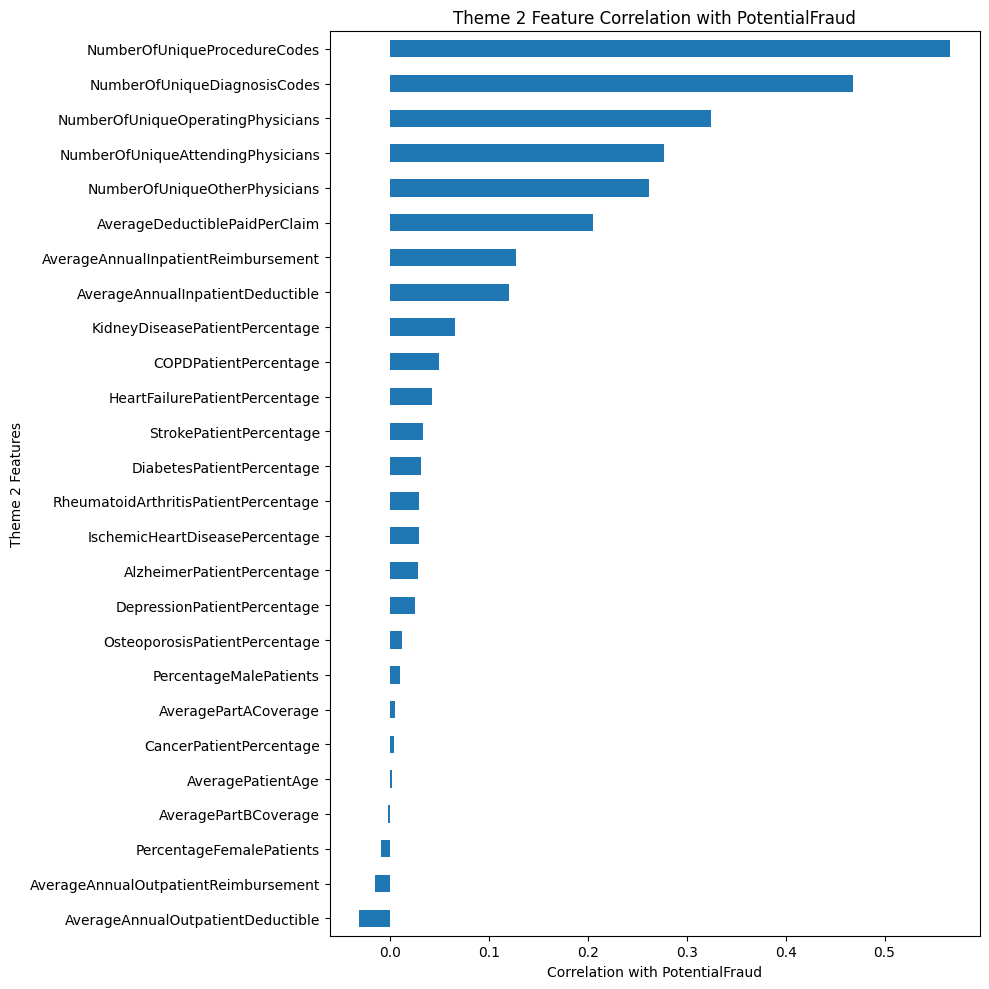

In [19]:
# --------------------------------------------
# 3. Horizontal Correlation Ranking Chart
# --------------------------------------------

plt.figure(figsize=(10, 10))

theme2_fraud_correlation.sort_values().plot(
    kind='barh'
)

plt.title('Theme 2 Feature Correlation with PotentialFraud')
plt.xlabel('Correlation with PotentialFraud')
plt.ylabel('Theme 2 Features')

plt.tight_layout()
plt.show()

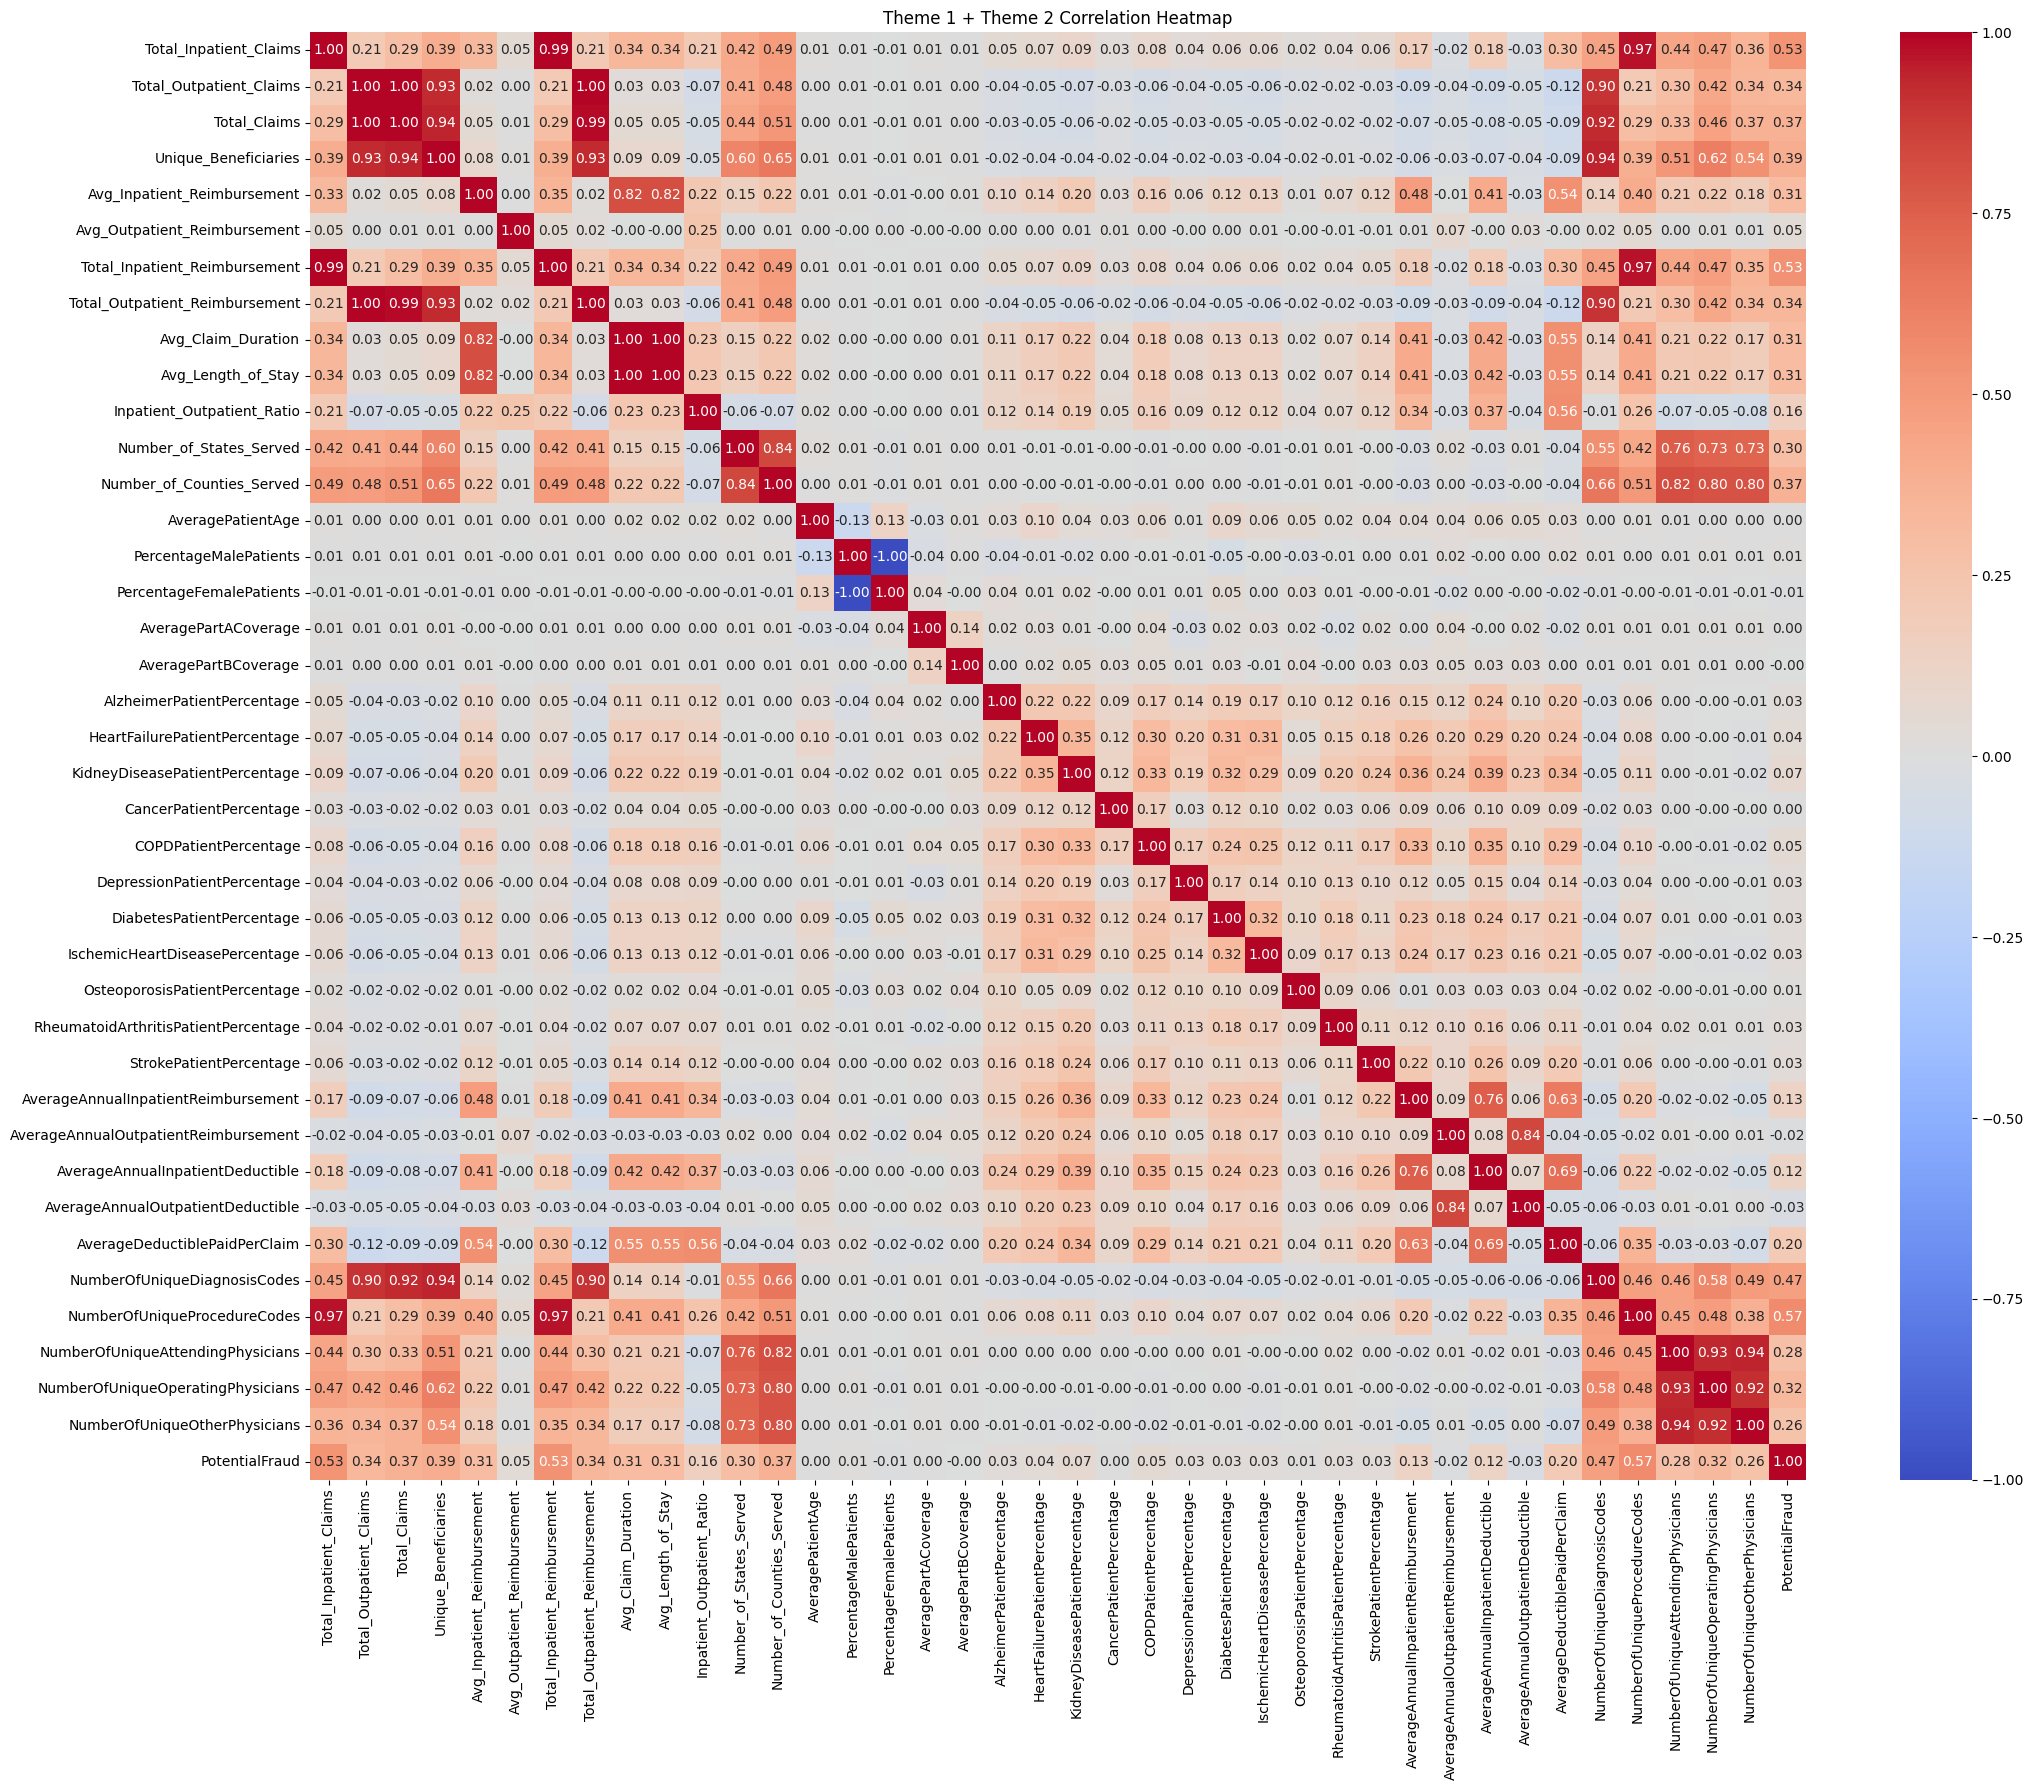

In [20]:
# ============================================
# Section 8.4: Combined Correlation Analysis
# ============================================

# Calculate correlations between all Theme 1 and Theme 2 features
theme12_correlation = theme12_corr.drop(columns=['Provider']).corr()

# --------------------------------------------
# 1. Correlation Heatmap
# --------------------------------------------

plt.figure(figsize=(22, 18))

sns.heatmap(
    theme12_correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Theme 1 + Theme 2 Correlation Heatmap')
plt.tight_layout()
plt.show()

In [21]:
# --------------------------------------------
# 2. Rank All Features Against PotentialFraud
# --------------------------------------------

theme12_fraud_correlation = (
    theme12_correlation['PotentialFraud']
    .drop('PotentialFraud')
    .sort_values(ascending=False)
)

print("Theme 1 + Theme 2 Feature Correlation with PotentialFraud:")
display(theme12_fraud_correlation)

Theme 1 + Theme 2 Feature Correlation with PotentialFraud:


,PotentialFraud
NumberOfUniqueProcedureCodes,0.566664
Total_Inpatient_Reimbursement,0.532795
Total_Inpatient_Claims,0.525393
NumberOfUniqueDiagnosisCodes,0.467892
Unique_Beneficiaries,0.393531
Total_Claims,0.374197
Number_of_Counties_Served,0.372852
Total_Outpatient_Reimbursement,0.337756
Total_Outpatient_Claims,0.335803
NumberOfUniqueOperatingPhysicians,0.324408


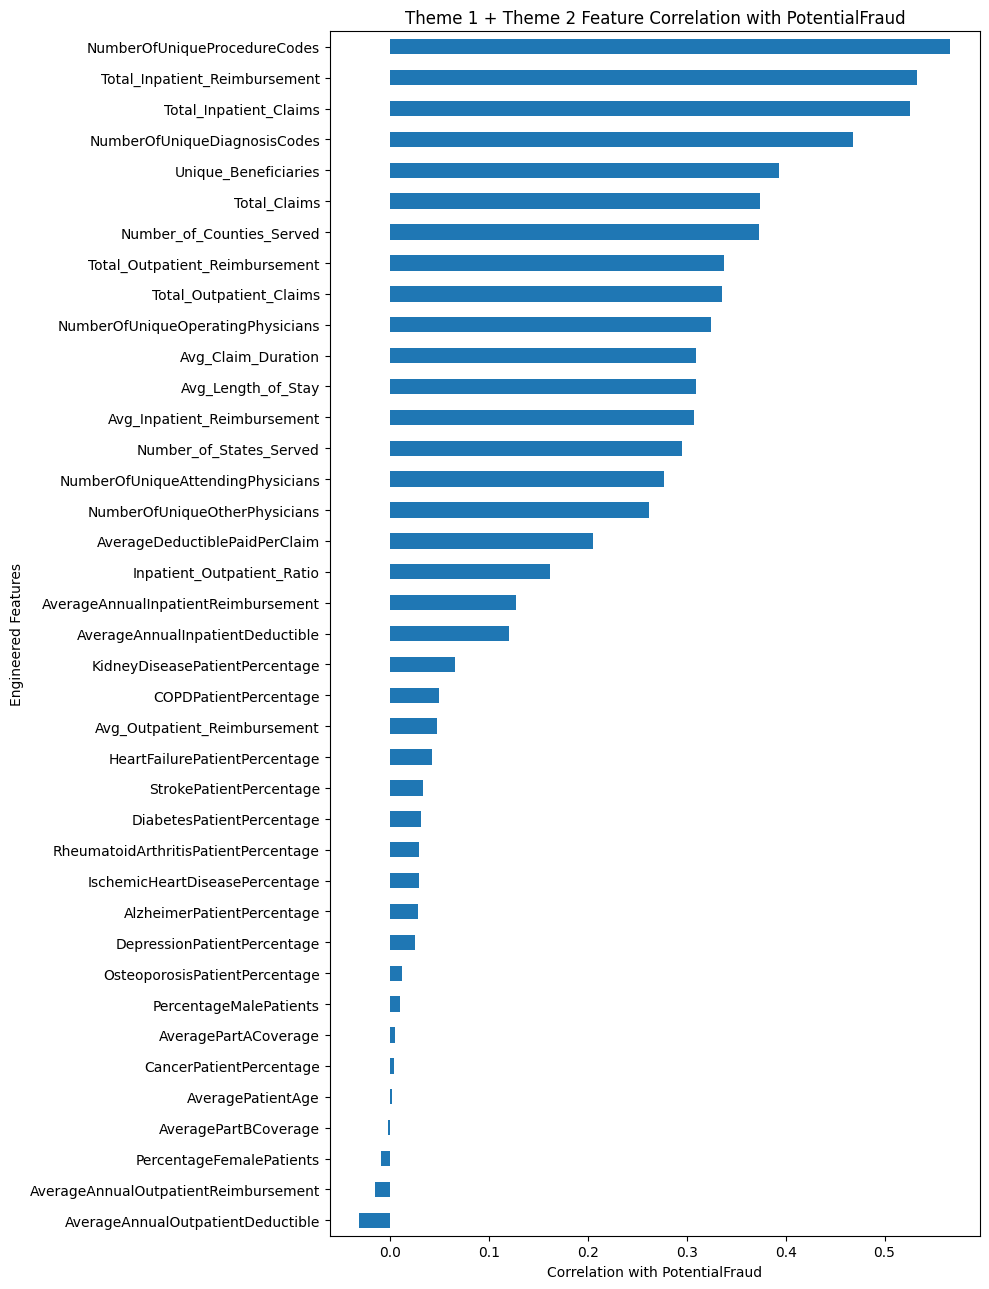

In [22]:
# --------------------------------------------
# 3. Horizontal Correlation Ranking Chart
# --------------------------------------------

plt.figure(figsize=(10, 13))

theme12_fraud_correlation.sort_values().plot(
    kind='barh'
)

plt.title('Theme 1 + Theme 2 Feature Correlation with PotentialFraud')
plt.xlabel('Correlation with PotentialFraud')
plt.ylabel('Engineered Features')

plt.tight_layout()
plt.show()

In [23]:
# ============================================
# Section 9: Feature Selection
# ============================================

# --------------------------------------------
# Section 9.1: Highly Correlated Theme 1 Features
# --------------------------------------------

# Identify highly correlated feature pairs in Theme 1
theme1_features = theme1_corr.drop(
    columns=['Provider', 'PotentialFraud']
)

theme1_feature_corr = theme1_features.corr()

high_corr_theme1 = []

for i in range(len(theme1_feature_corr.columns)):
    for j in range(i):
        correlation = theme1_feature_corr.iloc[i, j]

        if abs(correlation) >= 0.90:
            high_corr_theme1.append([
                theme1_feature_corr.columns[i],
                theme1_feature_corr.columns[j],
                correlation
            ])

high_corr_theme1 = pd.DataFrame(
    high_corr_theme1,
    columns=['Feature 1', 'Feature 2', 'Correlation']
)

high_corr_theme1

,Feature 1,Feature 2,Correlation
0,Total_Claims,Total_Outpatient_Claims,0.996374
1,Unique_Beneficiaries,Total_Outpatient_Claims,0.928435
2,Unique_Beneficiaries,Total_Claims,0.942310
3,Total_Inpatient_Reimbursement,Total_Inpatient_Claims,0.992523
4,Total_Outpatient_Reimbursement,Total_Outpatient_Claims,0.995092
5,Total_Outpatient_Reimbursement,Total_Claims,0.991937
6,Total_Outpatient_Reimbursement,Unique_Beneficiaries,0.925886
7,Avg_Length_of_Stay,Avg_Claim_Duration,0.999884


In [24]:
# ============================================
# Section 9.2: Theme 1 Feature Selection
# ============================================

# Remove highly redundant Theme 1 features
theme1_removed_features = [
    'Total_Outpatient_Claims',
    'Total_Outpatient_Reimbursement',
    'Total_Inpatient_Claims',
    'Avg_Length_of_Stay'
]

# Create the selected Theme 1 dataset
theme1_selected_data = theme1.drop(
    columns=theme1_removed_features
)

# Display selected features
print("Removed Theme 1 Features:")
print(theme1_removed_features)

print("\nRemaining Theme 1 Features:")
print(theme1_selected_data.columns.tolist())

print("\nDataset Shape:")
print(theme1_selected_data.shape)

Removed Theme 1 Features:
['Total_Outpatient_Claims', 'Total_Outpatient_Reimbursement', 'Total_Inpatient_Claims', 'Avg_Length_of_Stay']

Remaining Theme 1 Features:
['Provider', 'Total_Claims', 'Unique_Beneficiaries', 'Avg_Inpatient_Reimbursement', 'Avg_Outpatient_Reimbursement', 'Total_Inpatient_Reimbursement', 'Avg_Claim_Duration', 'Inpatient_Outpatient_Ratio', 'Number_of_States_Served', 'Number_of_Counties_Served', 'PotentialFraud']

Dataset Shape:
(5410, 11)


In [25]:
# ============================================
# Section 9.3: Highly Correlated Theme 2 Features
# ============================================

# Identify highly correlated feature pairs in Theme 2
theme2_features = theme2_corr.drop(
    columns=['Provider', 'PotentialFraud']
)

theme2_feature_corr = theme2_features.corr()

high_corr_theme2 = []

for i in range(len(theme2_feature_corr.columns)):
    for j in range(i):
        correlation = theme2_feature_corr.iloc[i, j]

        if abs(correlation) >= 0.90:
            high_corr_theme2.append([
                theme2_feature_corr.columns[i],
                theme2_feature_corr.columns[j],
                correlation
            ])

high_corr_theme2 = pd.DataFrame(
    high_corr_theme2,
    columns=['Feature 1', 'Feature 2', 'Correlation']
)

high_corr_theme2


,Feature 1,Feature 2,Correlation
0,PercentageFemalePatients,PercentageMalePatients,-1.000000
1,NumberOfUniqueOperatingPhysicians,NumberOfUniqueAttendingPhysicians,0.932974
2,NumberOfUniqueOtherPhysicians,NumberOfUniqueAttendingPhysicians,0.940375
3,NumberOfUniqueOtherPhysicians,NumberOfUniqueOperatingPhysicians,0.919676


In [26]:
# ============================================
# Section 9.4: Theme 2 Feature Selection
# ============================================

# Remove highly redundant Theme 2 features
theme2_removed_features = [
    'PercentageFemalePatients',
    'NumberOfUniqueAttendingPhysicians',
    'NumberOfUniqueOtherPhysicians'
]

# Create the selected Theme 2 dataset
theme2_selected_data = theme2.drop(
    columns=theme2_removed_features
)

# Display selected features
print("Removed Theme 2 Features:")
print(theme2_removed_features)

print("\nRemaining Theme 2 Features:")
print(theme2_selected_data.columns.tolist())

print("\nDataset Shape:")
print(theme2_selected_data.shape)

Removed Theme 2 Features:
['PercentageFemalePatients', 'NumberOfUniqueAttendingPhysicians', 'NumberOfUniqueOtherPhysicians']

Remaining Theme 2 Features:
['Provider', 'AveragePatientAge', 'PercentageMalePatients', 'AveragePartACoverage', 'AveragePartBCoverage', 'AlzheimerPatientPercentage', 'HeartFailurePatientPercentage', 'KidneyDiseasePatientPercentage', 'CancerPatientPercentage', 'COPDPatientPercentage', 'DepressionPatientPercentage', 'DiabetesPatientPercentage', 'IschemicHeartDiseasePercentage', 'OsteoporosisPatientPercentage', 'RheumatoidArthritisPatientPercentage', 'StrokePatientPercentage', 'AverageAnnualInpatientReimbursement', 'AverageAnnualOutpatientReimbursement', 'AverageAnnualInpatientDeductible', 'AverageAnnualOutpatientDeductible', 'AverageDeductiblePaidPerClaim', 'NumberOfUniqueDiagnosisCodes', 'NumberOfUniqueProcedureCodes', 'NumberOfUniqueOperatingPhysicians', 'PotentialFraud']

Dataset Shape:
(5410, 25)


In [27]:
# ============================================
# Section 9.5: Combined Dataset Feature Selection
# ============================================

# Combine the features removed from Theme 1 and Theme 2
combined_removed_features = (
    theme1_removed_features +
    theme2_removed_features
)

# Create the selected Theme 1 + Theme 2 dataset
theme12_selected_data = theme12.drop(
    columns=combined_removed_features
)

# Display removed features
print("Removed Features from Combined Dataset:")
print(combined_removed_features)

print("\nRemaining Features:")
print(theme12_selected_data.columns.tolist())

print("\nDataset Shape:")
print(theme12_selected_data.shape)


Removed Features from Combined Dataset:
['Total_Outpatient_Claims', 'Total_Outpatient_Reimbursement', 'Total_Inpatient_Claims', 'Avg_Length_of_Stay', 'PercentageFemalePatients', 'NumberOfUniqueAttendingPhysicians', 'NumberOfUniqueOtherPhysicians']

Remaining Features:
['Provider', 'Total_Claims', 'Unique_Beneficiaries', 'Avg_Inpatient_Reimbursement', 'Avg_Outpatient_Reimbursement', 'Total_Inpatient_Reimbursement', 'Avg_Claim_Duration', 'Inpatient_Outpatient_Ratio', 'Number_of_States_Served', 'Number_of_Counties_Served', 'AveragePatientAge', 'PercentageMalePatients', 'AveragePartACoverage', 'AveragePartBCoverage', 'AlzheimerPatientPercentage', 'HeartFailurePatientPercentage', 'KidneyDiseasePatientPercentage', 'CancerPatientPercentage', 'COPDPatientPercentage', 'DepressionPatientPercentage', 'DiabetesPatientPercentage', 'IschemicHeartDiseasePercentage', 'OsteoporosisPatientPercentage', 'RheumatoidArthritisPatientPercentage', 'StrokePatientPercentage', 'AverageAnnualInpatientReimbursement

In [28]:
# ============================================
# Section 10: Data Splitting
# ============================================

# --------------------------------------------
# Section 10.1: Define Features and Target
# --------------------------------------------

# Define Theme 1 features and target
X_theme1 = theme1_selected_data.drop(
    columns=['Provider', 'PotentialFraud']
)
y_theme1 = theme1_selected_data['PotentialFraud']

# Define Theme 2 features and target
X_theme2 = theme2_selected_data.drop(
    columns=['Provider', 'PotentialFraud']
)
y_theme2 = theme2_selected_data['PotentialFraud']

# Define Theme 1 + Theme 2 features and target
X_theme12 = theme12_selected_data.drop(
    columns=['Provider', 'PotentialFraud']
)
y_theme12 = theme12_selected_data['PotentialFraud']


# Display dimensions
print("Theme 1:")
print("X Shape:", X_theme1.shape)
print("y Shape:", y_theme1.shape)

print("\nTheme 2:")
print("X Shape:", X_theme2.shape)
print("y Shape:", y_theme2.shape)

print("\nTheme 1 + Theme 2:")
print("X Shape:", X_theme12.shape)
print("y Shape:", y_theme12.shape)

Theme 1:
X Shape: (5410, 9)
y Shape: (5410,)

Theme 2:
X Shape: (5410, 23)
y Shape: (5410,)

Theme 1 + Theme 2:
X Shape: (5410, 32)
y Shape: (5410,)


In [29]:
# ============================================
# Section 10.2: Train/Test Split
# ============================================

# Split Theme 1 into 80% training and 20% testing data
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X_theme1,
    y_theme1,
    test_size=0.20,
    random_state=42,
    stratify=y_theme1
)

# Split Theme 2 into 80% training and 20% testing data
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_theme2,
    y_theme2,
    test_size=0.20,
    random_state=42,
    stratify=y_theme2
)

# Split Theme 1 + Theme 2 into 80% training and 20% testing data
X12_train, X12_test, y12_train, y12_test = train_test_split(
    X_theme12,
    y_theme12,
    test_size=0.20,
    random_state=42,
    stratify=y_theme12
)

print("Theme 1:")
print("Training Set:", X1_train.shape)
print("Testing Set:", X1_test.shape)

print("\nTheme 2:")
print("Training Set:", X2_train.shape)
print("Testing Set:", X2_test.shape)

print("\nTheme 1 + Theme 2:")
print("Training Set:", X12_train.shape)
print("Testing Set:", X12_test.shape)

Theme 1:
Training Set: (4328, 9)
Testing Set: (1082, 9)

Theme 2:
Training Set: (4328, 23)
Testing Set: (1082, 23)

Theme 1 + Theme 2:
Training Set: (4328, 32)
Testing Set: (1082, 32)


In [30]:
# ============================================
# Section 10.3: Verify Class Distribution
# ============================================

# Check class distribution in the training set
print("Training Set Class Distribution:")
print(y1_train.value_counts())

print("\nTraining Set Percentage:")
print((y1_train.value_counts(normalize=True) * 100).round(2))

# Check class distribution in the testing set
print("\nTesting Set Class Distribution:")
print(y1_test.value_counts())

print("\nTesting Set Percentage:")
print((y1_test.value_counts(normalize=True) * 100).round(2))

Training Set Class Distribution:
PotentialFraud
No     3923
Yes     405
Name: count, dtype: int64

Training Set Percentage:
PotentialFraud
No     90.64
Yes     9.36
Name: proportion, dtype: float64

Testing Set Class Distribution:
PotentialFraud
No     981
Yes    101
Name: count, dtype: int64

Testing Set Percentage:
PotentialFraud
No     90.67
Yes     9.33
Name: proportion, dtype: float64


In [31]:
# ============================================
# Section 11: Class Balancing Using SMOTE
# ============================================

# --------------------------------------------
# Section 11.1: Apply SMOTE to Training Sets
# --------------------------------------------

#Import SMOTE Library
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to Theme 1 training data
X1_train_smote, y1_train_smote = smote.fit_resample(
    X1_train, y1_train
)

# Apply SMOTE to Theme 2 training data
X2_train_smote, y2_train_smote = smote.fit_resample(
    X2_train, y2_train
)

# Apply SMOTE to Theme 1 + Theme 2 training data
X12_train_smote, y12_train_smote = smote.fit_resample(
    X12_train, y12_train
)

print("Theme 1 After SMOTE:")
print(y1_train_smote.value_counts())

print("\nTheme 2 After SMOTE:")
print(y2_train_smote.value_counts())

print("\nTheme 1 + Theme 2 After SMOTE:")
print(y12_train_smote.value_counts())

Theme 1 After SMOTE:
PotentialFraud
No     3923
Yes    3923
Name: count, dtype: int64

Theme 2 After SMOTE:
PotentialFraud
No     3923
Yes    3923
Name: count, dtype: int64

Theme 1 + Theme 2 After SMOTE:
PotentialFraud
No     3923
Yes    3923
Name: count, dtype: int64


In [32]:
# ============================================
# Section 12: Feature Scaling
# ============================================

# --------------------------------------------
# Section 12.1: Standardize Features
# --------------------------------------------

#Import StandardScaler Library
from sklearn.preprocessing import StandardScaler

# Initialize separate scalers for each dataset
scaler1 = StandardScaler()
scaler2 = StandardScaler()
scaler12 = StandardScaler()

# Scale Theme 1
X1_train_scaled = scaler1.fit_transform(X1_train_smote)
X1_test_scaled = scaler1.transform(X1_test)

# Scale Theme 2
X2_train_scaled = scaler2.fit_transform(X2_train_smote)
X2_test_scaled = scaler2.transform(X2_test)

# Scale Theme 1 + Theme 2
X12_train_scaled = scaler12.fit_transform(X12_train_smote)
X12_test_scaled = scaler12.transform(X12_test)

# Display dimensions
print("Theme 1:")
print("Scaled Training Set:", X1_train_scaled.shape)
print("Scaled Testing Set:", X1_test_scaled.shape)

print("\nTheme 2:")
print("Scaled Training Set:", X2_train_scaled.shape)
print("Scaled Testing Set:", X2_test_scaled.shape)

print("\nTheme 1 + Theme 2:")
print("Scaled Training Set:", X12_train_scaled.shape)
print("Scaled Testing Set:", X12_test_scaled.shape)

Theme 1:
Scaled Training Set: (7846, 9)
Scaled Testing Set: (1082, 9)

Theme 2:
Scaled Training Set: (7846, 23)
Scaled Testing Set: (1082, 23)

Theme 1 + Theme 2:
Scaled Training Set: (7846, 32)
Scaled Testing Set: (1082, 32)


# **Section 13.1 — Logistic Regression**

In [33]:
#Import LogisticRegression Library and the evaluation metrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Import libraries for hyperparameter tuning
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer

from imblearn.pipeline import Pipeline

In [34]:
# ============================================
# Section 13: Model Development
# ============================================

# --------------------------------------------
# Section 13.1: Logistic Regression Tuning
# --------------------------------------------

# Use stratified 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Use fraud class (Yes) for F1-score optimization
f1_scorer = make_scorer(
    f1_score,
    pos_label='Yes'
)

In [35]:
# Create Logistic Regression pipeline
lr_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

# Define Logistic Regression hyperparameters
lr_param_grid = {
    'logistic__C': [0.01, 0.1, 1, 10, 100],
    'logistic__penalty': ['l1', 'l2'],
    'logistic__solver': ['liblinear']
}



In [36]:
# --------------------------------------------
# Logistic Regression - Theme 1
# --------------------------------------------

lr_grid_theme1 = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    scoring=f1_scorer,
    cv=cv,
    n_jobs=-1
)

lr_grid_theme1.fit(
    X1_train,
    y1_train
)

print("Theme 1 Best Parameters:")
print(lr_grid_theme1.best_params_)

print("\nTheme 1 Best Cross-Validation F1-Score:")
print(round(lr_grid_theme1.best_score_, 4))

Theme 1 Best Parameters:
{'logistic__C': 10, 'logistic__penalty': 'l1', 'logistic__solver': 'liblinear'}

Theme 1 Best Cross-Validation F1-Score:
0.5554


In [37]:
# --------------------------------------------
# Logistic Regression - Theme 2
# --------------------------------------------

lr_grid_theme2 = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    scoring=f1_scorer,
    cv=cv,
    n_jobs=-1
)

lr_grid_theme2.fit(
    X2_train,
    y2_train
)

print("Theme 2 Best Parameters:")
print(lr_grid_theme2.best_params_)

print("\nTheme 2 Best Cross-Validation F1-Score:")
print(round(lr_grid_theme2.best_score_, 4))

Theme 2 Best Parameters:
{'logistic__C': 0.01, 'logistic__penalty': 'l1', 'logistic__solver': 'liblinear'}

Theme 2 Best Cross-Validation F1-Score:
0.5634


In [38]:
# --------------------------------------------
# Logistic Regression - Theme 1 + Theme 2
# --------------------------------------------

lr_grid_theme12 = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    scoring=f1_scorer,
    cv=cv,
    n_jobs=-1
)

lr_grid_theme12.fit(
    X12_train,
    y12_train
)

print("Theme 1 + Theme 2 Best Parameters:")
print(lr_grid_theme12.best_params_)

print("\nTheme 1 + Theme 2 Best Cross-Validation F1-Score:")
print(round(lr_grid_theme12.best_score_, 4))

Theme 1 + Theme 2 Best Parameters:
{'logistic__C': 0.01, 'logistic__penalty': 'l1', 'logistic__solver': 'liblinear'}

Theme 1 + Theme 2 Best Cross-Validation F1-Score:
0.5386


Logistic Regression Theme 1

In [39]:
# Get the best Logistic Regression model for Theme 1
best_lr_theme1 = lr_grid_theme1.best_estimator_

# Predict the untouched Theme 1 test set
y1_pred_lr = best_lr_theme1.predict(X1_test)

# Get fraud probability for ROC-AUC
y1_prob_lr = best_lr_theme1.predict_proba(X1_test)[:, 1]

In [40]:
# Calculate Logistic Regression evaluation metrics - Theme 1
lr1_precision = precision_score(
    y1_test,
    y1_pred_lr,
    pos_label='Yes'
)

lr1_recall = recall_score(
    y1_test,
    y1_pred_lr,
    pos_label='Yes'
)

lr1_f1 = f1_score(
    y1_test,
    y1_pred_lr,
    pos_label='Yes'
)

lr1_accuracy = accuracy_score(
    y1_test,
    y1_pred_lr
)

lr1_roc = roc_auc_score(
    (y1_test == 'Yes').astype(int),
    y1_prob_lr
)

print("Logistic Regression - Theme 1")
print("Precision:", round(lr1_precision, 4))
print("Recall:", round(lr1_recall, 4))
print("F1-Score:", round(lr1_f1, 4))
print("Accuracy:", round(lr1_accuracy, 4))
print("ROC-AUC:", round(lr1_roc, 4))

Logistic Regression - Theme 1
Precision: 0.4194
Recall: 0.901
F1-Score: 0.5723
Accuracy: 0.8743
ROC-AUC: 0.9602


Logistic Regression Theme 2

In [41]:
# Get the best Logistic Regression model for Theme 2
best_lr_theme2 = lr_grid_theme2.best_estimator_

# Predict the untouched Theme 2 test set
y2_pred_lr = best_lr_theme2.predict(X2_test)

# Get fraud probability for ROC-AUC
y2_prob_lr = best_lr_theme2.predict_proba(X2_test)[:, 1]

In [42]:
# Calculate Logistic Regression evaluation metrics - Theme 2
lr2_precision = precision_score(
    y2_test,
    y2_pred_lr,
    pos_label='Yes'
)

lr2_recall = recall_score(
    y2_test,
    y2_pred_lr,
    pos_label='Yes'
)

lr2_f1 = f1_score(
    y2_test,
    y2_pred_lr,
    pos_label='Yes'
)

lr2_accuracy = accuracy_score(
    y2_test,
    y2_pred_lr
)

lr2_roc = roc_auc_score(
    (y2_test == 'Yes').astype(int),
    y2_prob_lr
)

print("Logistic Regression - Theme 2")
print("Precision:", round(lr2_precision, 4))
print("Recall:", round(lr2_recall, 4))
print("F1-Score:", round(lr2_f1, 4))
print("Accuracy:", round(lr2_accuracy, 4))
print("ROC-AUC:", round(lr2_roc, 4))

Logistic Regression - Theme 2
Precision: 0.4854
Recall: 0.8218
F1-Score: 0.6103
Accuracy: 0.902
ROC-AUC: 0.9505


Logistic Regression Theme 1 + Theme 2

In [43]:
# Get the best Logistic Regression model for Theme 1 + Theme 2
best_lr_theme12 = lr_grid_theme12.best_estimator_

# Predict the untouched Theme 1 + Theme 2 test set
y12_pred_lr = best_lr_theme12.predict(X12_test)

# Get fraud probability for ROC-AUC
y12_prob_lr = best_lr_theme12.predict_proba(X12_test)[:, 1]

In [44]:
# Calculate Logistic Regression evaluation metrics - Theme 1 + Theme 2
lr12_precision = precision_score(
    y12_test,
    y12_pred_lr,
    pos_label='Yes'
)

lr12_recall = recall_score(
    y12_test,
    y12_pred_lr,
    pos_label='Yes'
)

lr12_f1 = f1_score(
    y12_test,
    y12_pred_lr,
    pos_label='Yes'
)

lr12_accuracy = accuracy_score(
    y12_test,
    y12_pred_lr
)

lr12_roc = roc_auc_score(
    (y12_test == 'Yes').astype(int),
    y12_prob_lr
)

print("Logistic Regression - Theme 1 + Theme 2")
print("Precision:", round(lr12_precision, 4))
print("Recall:", round(lr12_recall, 4))
print("F1-Score:", round(lr12_f1, 4))
print("Accuracy:", round(lr12_accuracy, 4))
print("ROC-AUC:", round(lr12_roc, 4))

Logistic Regression - Theme 1 + Theme 2
Precision: 0.3991
Recall: 0.901
F1-Score: 0.5532
Accuracy: 0.8641
ROC-AUC: 0.952


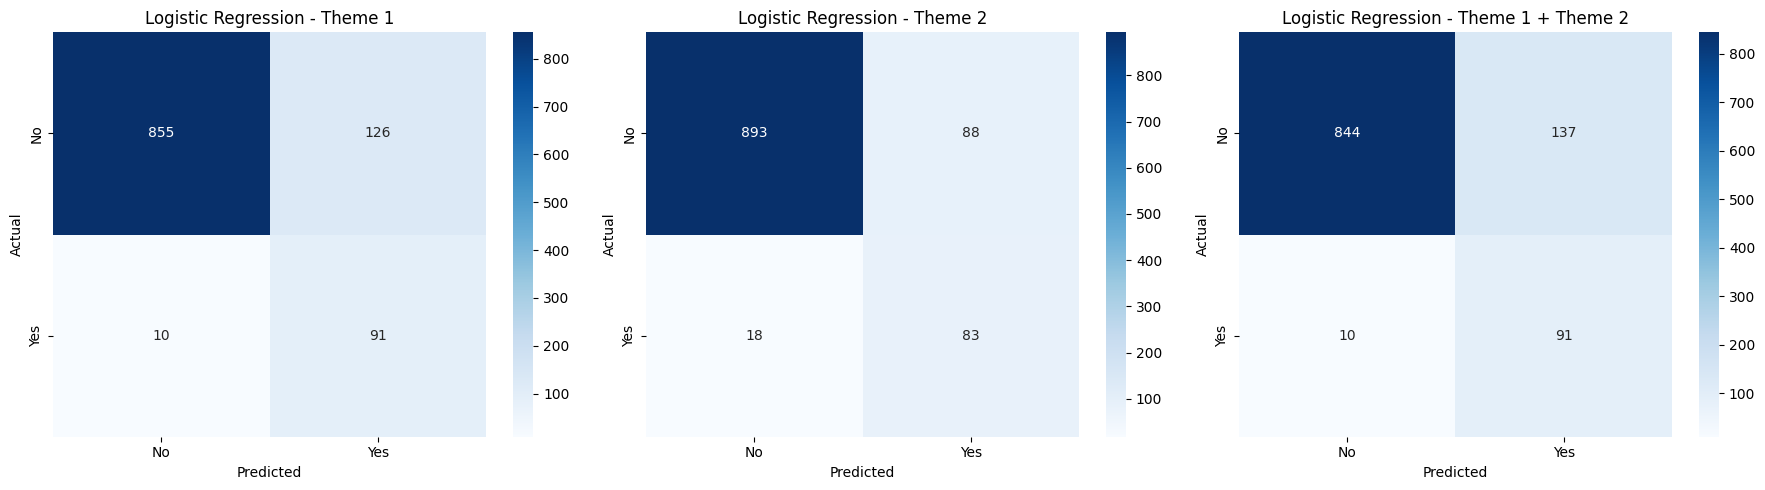

In [45]:
# ============================================
# Logistic Regression Confusion Matrices
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Theme 1
sns.heatmap(
    confusion_matrix(y1_test, y1_pred_lr, labels=['No', 'Yes']),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes'],
    ax=axes[0]
)
axes[0].set_title('Logistic Regression - Theme 1')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Theme 2
sns.heatmap(
    confusion_matrix(y2_test, y2_pred_lr, labels=['No', 'Yes']),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes'],
    ax=axes[1]
)
axes[1].set_title('Logistic Regression - Theme 2')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Theme 1 + Theme 2
sns.heatmap(
    confusion_matrix(y12_test, y12_pred_lr, labels=['No', 'Yes']),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes'],
    ax=axes[2]
)
axes[2].set_title('Logistic Regression - Theme 1 + Theme 2')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# **Section 13.2 — Random Forest**

In [46]:
# Import Random Forest Library
from sklearn.ensemble import RandomForestClassifier

In [47]:
# Create Random Forest pipeline
rf_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('random_forest', RandomForestClassifier(
        random_state=42
    ))
])

In [48]:
# Define Random Forest hyperparameters
rf_param_grid = {
    'random_forest__n_estimators': [100, 200],
    'random_forest__max_depth': [None, 10, 20],
    'random_forest__min_samples_split': [2, 5],
    'random_forest__min_samples_leaf': [1, 2]
}

Random Forest Theme 1

In [49]:
# --------------------------------------------
# Random Forest - Theme 1
# --------------------------------------------

rf_grid_theme1 = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring=f1_scorer,
    cv=cv,
    n_jobs=-1
)

rf_grid_theme1.fit(
    X1_train,
    y1_train
)

print("Theme 1 Best Parameters:")
print(rf_grid_theme1.best_params_)

print("\nTheme 1 Best Cross-Validation F1-Score:")
print(round(rf_grid_theme1.best_score_, 4))

Theme 1 Best Parameters:
{'random_forest__max_depth': 20, 'random_forest__min_samples_leaf': 2, 'random_forest__min_samples_split': 2, 'random_forest__n_estimators': 200}

Theme 1 Best Cross-Validation F1-Score:
0.5934


Random Forest Theme 2

In [50]:
# --------------------------------------------
# Random Forest - Theme 2
# --------------------------------------------

rf_grid_theme2 = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring=f1_scorer,
    cv=cv,
    n_jobs=-1
)

rf_grid_theme2.fit(
    X2_train,
    y2_train
)

print("Theme 2 Best Parameters:")
print(rf_grid_theme2.best_params_)

print("\nTheme 2 Best Cross-Validation F1-Score:")
print(round(rf_grid_theme2.best_score_, 4))

Theme 2 Best Parameters:
{'random_forest__max_depth': None, 'random_forest__min_samples_leaf': 2, 'random_forest__min_samples_split': 2, 'random_forest__n_estimators': 200}

Theme 2 Best Cross-Validation F1-Score:
0.5614


Random Forest Theme 1 + Theme 2

In [51]:
# --------------------------------------------
# Random Forest - Theme 1 + Theme 2
# --------------------------------------------

rf_grid_theme12 = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring=f1_scorer,
    cv=cv,
    n_jobs=-1
)

rf_grid_theme12.fit(
    X12_train,
    y12_train
)

print("Theme 1 + Theme 2 Best Parameters:")
print(rf_grid_theme12.best_params_)

print("\nTheme 1 + Theme 2 Best Cross-Validation F1-Score:")
print(round(rf_grid_theme12.best_score_, 4))

Theme 1 + Theme 2 Best Parameters:
{'random_forest__max_depth': None, 'random_forest__min_samples_leaf': 2, 'random_forest__min_samples_split': 5, 'random_forest__n_estimators': 100}

Theme 1 + Theme 2 Best Cross-Validation F1-Score:
0.5852


In [52]:
# Get the best Random Forest model for Theme 1
best_rf_theme1 = rf_grid_theme1.best_estimator_

# Predict the untouched Theme 1 test set
y1_pred_rf = best_rf_theme1.predict(X1_test)

# Get fraud probability for ROC-AUC
y1_prob_rf = best_rf_theme1.predict_proba(X1_test)[:, 1]


# Calculate Random Forest evaluation metrics - Theme 1
rf1_precision = precision_score(
    y1_test,
    y1_pred_rf,
    pos_label='Yes'
)

rf1_recall = recall_score(
    y1_test,
    y1_pred_rf,
    pos_label='Yes'
)

rf1_f1 = f1_score(
    y1_test,
    y1_pred_rf,
    pos_label='Yes'
)

rf1_accuracy = accuracy_score(
    y1_test,
    y1_pred_rf
)

rf1_roc = roc_auc_score(
    (y1_test == 'Yes').astype(int),
    y1_prob_rf
)

print("Random Forest - Theme 1")
print("Precision:", round(rf1_precision, 4))
print("Recall:", round(rf1_recall, 4))
print("F1-Score:", round(rf1_f1, 4))
print("Accuracy:", round(rf1_accuracy, 4))
print("ROC-AUC:", round(rf1_roc, 4))

Random Forest - Theme 1
Precision: 0.5031
Recall: 0.7921
F1-Score: 0.6154
Accuracy: 0.9076
ROC-AUC: 0.9519


In [53]:
# Get the best Random Forest model for Theme 2
best_rf_theme2 = rf_grid_theme2.best_estimator_

# Predict the untouched Theme 2 test set
y2_pred_rf = best_rf_theme2.predict(X2_test)

# Get fraud probability for ROC-AUC
y2_prob_rf = best_rf_theme2.predict_proba(X2_test)[:, 1]


# Calculate Random Forest evaluation metrics - Theme 2
rf2_precision = precision_score(
    y2_test,
    y2_pred_rf,
    pos_label='Yes'
)

rf2_recall = recall_score(
    y2_test,
    y2_pred_rf,
    pos_label='Yes'
)

rf2_f1 = f1_score(
    y2_test,
    y2_pred_rf,
    pos_label='Yes'
)

rf2_accuracy = accuracy_score(
    y2_test,
    y2_pred_rf
)

rf2_roc = roc_auc_score(
    (y2_test == 'Yes').astype(int),
    y2_prob_rf
)

print("Random Forest - Theme 2")
print("Precision:", round(rf2_precision, 4))
print("Recall:", round(rf2_recall, 4))
print("F1-Score:", round(rf2_f1, 4))
print("Accuracy:", round(rf2_accuracy, 4))
print("ROC-AUC:", round(rf2_roc, 4))

Random Forest - Theme 2
Precision: 0.5168
Recall: 0.7624
F1-Score: 0.616
Accuracy: 0.9113
ROC-AUC: 0.9387


In [54]:
# Get the best Random Forest model for Theme 1 + Theme 2
best_rf_theme12 = rf_grid_theme12.best_estimator_

# Predict the untouched Theme 1 + Theme 2 test set
y12_pred_rf = best_rf_theme12.predict(X12_test)

# Get fraud probability for ROC-AUC
y12_prob_rf = best_rf_theme12.predict_proba(X12_test)[:, 1]


# Calculate Random Forest evaluation metrics - Theme 1 + Theme 2
rf12_precision = precision_score(
    y12_test,
    y12_pred_rf,
    pos_label='Yes'
)

rf12_recall = recall_score(
    y12_test,
    y12_pred_rf,
    pos_label='Yes'
)

rf12_f1 = f1_score(
    y12_test,
    y12_pred_rf,
    pos_label='Yes'
)

rf12_accuracy = accuracy_score(
    y12_test,
    y12_pred_rf
)

rf12_roc = roc_auc_score(
    (y12_test == 'Yes').astype(int),
    y12_prob_rf
)

print("Random Forest - Theme 1 + Theme 2")
print("Precision:", round(rf12_precision, 4))
print("Recall:", round(rf12_recall, 4))
print("F1-Score:", round(rf12_f1, 4))
print("Accuracy:", round(rf12_accuracy, 4))
print("ROC-AUC:", round(rf12_roc, 4))

Random Forest - Theme 1 + Theme 2
Precision: 0.5
Recall: 0.7624
F1-Score: 0.6039
Accuracy: 0.9067
ROC-AUC: 0.9442


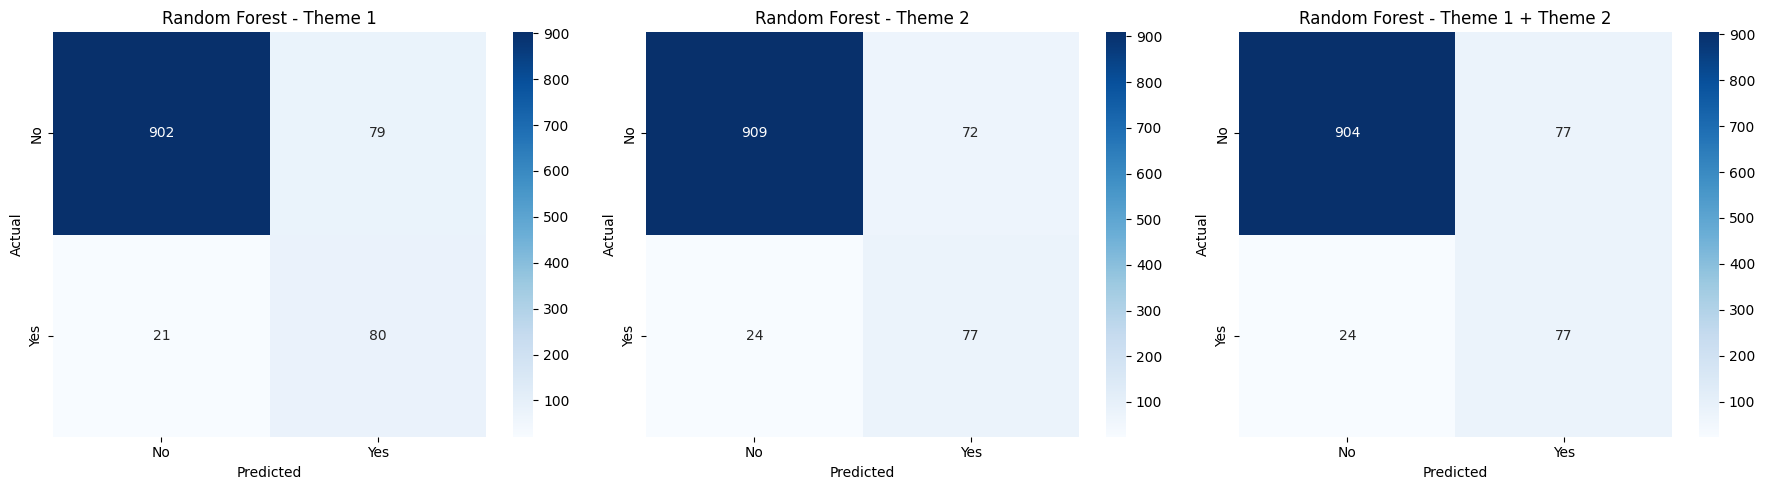

In [55]:
# ============================================
# Random Forest Confusion Matrices
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Theme 1
sns.heatmap(
    confusion_matrix(y1_test, y1_pred_rf, labels=['No', 'Yes']),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes'],
    ax=axes[0]
)

axes[0].set_title('Random Forest - Theme 1')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')


# Theme 2
sns.heatmap(
    confusion_matrix(y2_test, y2_pred_rf, labels=['No', 'Yes']),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes'],
    ax=axes[1]
)

axes[1].set_title('Random Forest - Theme 2')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')


# Theme 1 + Theme 2
sns.heatmap(
    confusion_matrix(y12_test, y12_pred_rf, labels=['No', 'Yes']),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes'],
    ax=axes[2]
)

axes[2].set_title('Random Forest - Theme 1 + Theme 2')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# **Section 13.3 — Support Vector Machine**

In [56]:
# ==================================================
# Section 13.3: Support Vector Machine
# ==================================================

# Import Support Vector Machine
from sklearn.svm import SVC

In [57]:
# Create Support Vector Machine pipeline
svm_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('svm', SVC(
        probability=True,
        random_state=42
    ))
])

In [58]:
# Define Support Vector Machine hyperparameters
svm_param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto']
}

Support Vector Machine Theme 1

In [59]:
# --------------------------------------------
# Support Vector Machine - Theme 1
# --------------------------------------------

svm_grid_theme1 = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring=f1_scorer,
    cv=cv,
    n_jobs=-1
)

svm_grid_theme1.fit(
    X1_train,
    y1_train
)

print("Theme 1 Best Parameters:")
print(svm_grid_theme1.best_params_)

print("\nTheme 1 Best Cross-Validation F1-Score:")
print(round(svm_grid_theme1.best_score_, 4))

Theme 1 Best Parameters:
{'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}

Theme 1 Best Cross-Validation F1-Score:
0.5461


In [60]:
# Get the best Support Vector Machine model for Theme 1
best_svm_theme1 = svm_grid_theme1.best_estimator_

# Predict the untouched Theme 1 test set
y1_pred_svm = best_svm_theme1.predict(X1_test)

# Get fraud probability for ROC-AUC
y1_prob_svm = best_svm_theme1.predict_proba(X1_test)[:, 1]


# Calculate Support Vector Machine evaluation metrics - Theme 1
svm1_precision = precision_score(
    y1_test,
    y1_pred_svm,
    pos_label='Yes'
)

svm1_recall = recall_score(
    y1_test,
    y1_pred_svm,
    pos_label='Yes'
)

svm1_f1 = f1_score(
    y1_test,
    y1_pred_svm,
    pos_label='Yes'
)

svm1_accuracy = accuracy_score(
    y1_test,
    y1_pred_svm
)

svm1_roc = roc_auc_score(
    (y1_test == 'Yes').astype(int),
    y1_prob_svm
)

print("Support Vector Machine - Theme 1")
print("Precision:", round(svm1_precision, 4))
print("Recall:", round(svm1_recall, 4))
print("F1-Score:", round(svm1_f1, 4))
print("Accuracy:", round(svm1_accuracy, 4))
print("ROC-AUC:", round(svm1_roc, 4))

Support Vector Machine - Theme 1
Precision: 0.4091
Recall: 0.8911
F1-Score: 0.5607
Accuracy: 0.8697
ROC-AUC: 0.9609


Support Vector Machine Theme 2

In [61]:
# --------------------------------------------
# Support Vector Machine - Theme 2
# --------------------------------------------

svm_grid_theme2 = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring=f1_scorer,
    cv=cv,
    n_jobs=-1
)

svm_grid_theme2.fit(
    X2_train,
    y2_train
)

print("Theme 2 Best Parameters:")
print(svm_grid_theme2.best_params_)

print("\nTheme 2 Best Cross-Validation F1-Score:")
print(round(svm_grid_theme2.best_score_, 4))

Theme 2 Best Parameters:
{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}

Theme 2 Best Cross-Validation F1-Score:
0.555


In [62]:
# Get the best Support Vector Machine model for Theme 2
best_svm_theme2 = svm_grid_theme2.best_estimator_

# Predict the untouched Theme 2 test set
y2_pred_svm = best_svm_theme2.predict(X2_test)

# Get fraud probability for ROC-AUC
y2_prob_svm = best_svm_theme2.predict_proba(X2_test)[:, 1]


# Calculate Support Vector Machine evaluation metrics - Theme 2
svm2_precision = precision_score(
    y2_test,
    y2_pred_svm,
    pos_label='Yes'
)

svm2_recall = recall_score(
    y2_test,
    y2_pred_svm,
    pos_label='Yes'
)

svm2_f1 = f1_score(
    y2_test,
    y2_pred_svm,
    pos_label='Yes'
)

svm2_accuracy = accuracy_score(
    y2_test,
    y2_pred_svm
)

svm2_roc = roc_auc_score(
    (y2_test == 'Yes').astype(int),
    y2_prob_svm
)

print("Support Vector Machine - Theme 2")
print("Precision:", round(svm2_precision, 4))
print("Recall:", round(svm2_recall, 4))
print("F1-Score:", round(svm2_f1, 4))
print("Accuracy:", round(svm2_accuracy, 4))
print("ROC-AUC:", round(svm2_roc, 4))

Support Vector Machine - Theme 2
Precision: 0.4439
Recall: 0.8614
F1-Score: 0.5859
Accuracy: 0.8863
ROC-AUC: 0.9523


Support Vector Machine Theme 1 + Theme 2

In [63]:
# --------------------------------------------
# Support Vector Machine - Theme 1 + Theme 2
# --------------------------------------------

svm_grid_theme12 = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring=f1_scorer,
    cv=cv,
    n_jobs=-1
)

svm_grid_theme12.fit(
    X12_train,
    y12_train
)

print("Theme 1 + Theme 2 Best Parameters:")
print(svm_grid_theme12.best_params_)

print("\nTheme 1 + Theme 2 Best Cross-Validation F1-Score:")
print(round(svm_grid_theme12.best_score_, 4))

Theme 1 + Theme 2 Best Parameters:
{'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

Theme 1 + Theme 2 Best Cross-Validation F1-Score:
0.5368


In [64]:
# Get the best Support Vector Machine model for Theme 1 + Theme 2
best_svm_theme12 = svm_grid_theme12.best_estimator_

# Predict the untouched Theme 1 + Theme 2 test set
y12_pred_svm = best_svm_theme12.predict(X12_test)

# Get fraud probability for ROC-AUC
y12_prob_svm = best_svm_theme12.predict_proba(X12_test)[:, 1]


# Calculate Support Vector Machine evaluation metrics - Theme 1 + Theme 2
svm12_precision = precision_score(
    y12_test,
    y12_pred_svm,
    pos_label='Yes'
)

svm12_recall = recall_score(
    y12_test,
    y12_pred_svm,
    pos_label='Yes'
)

svm12_f1 = f1_score(
    y12_test,
    y12_pred_svm,
    pos_label='Yes'
)

svm12_accuracy = accuracy_score(
    y12_test,
    y12_pred_svm
)

svm12_roc = roc_auc_score(
    (y12_test == 'Yes').astype(int),
    y12_prob_svm
)

print("Support Vector Machine - Theme 1 + Theme 2")
print("Precision:", round(svm12_precision, 4))
print("Recall:", round(svm12_recall, 4))
print("F1-Score:", round(svm12_f1, 4))
print("Accuracy:", round(svm12_accuracy, 4))
print("ROC-AUC:", round(svm12_roc, 4))

Support Vector Machine - Theme 1 + Theme 2
Precision: 0.4171
Recall: 0.8713
F1-Score: 0.5641
Accuracy: 0.8743
ROC-AUC: 0.9384


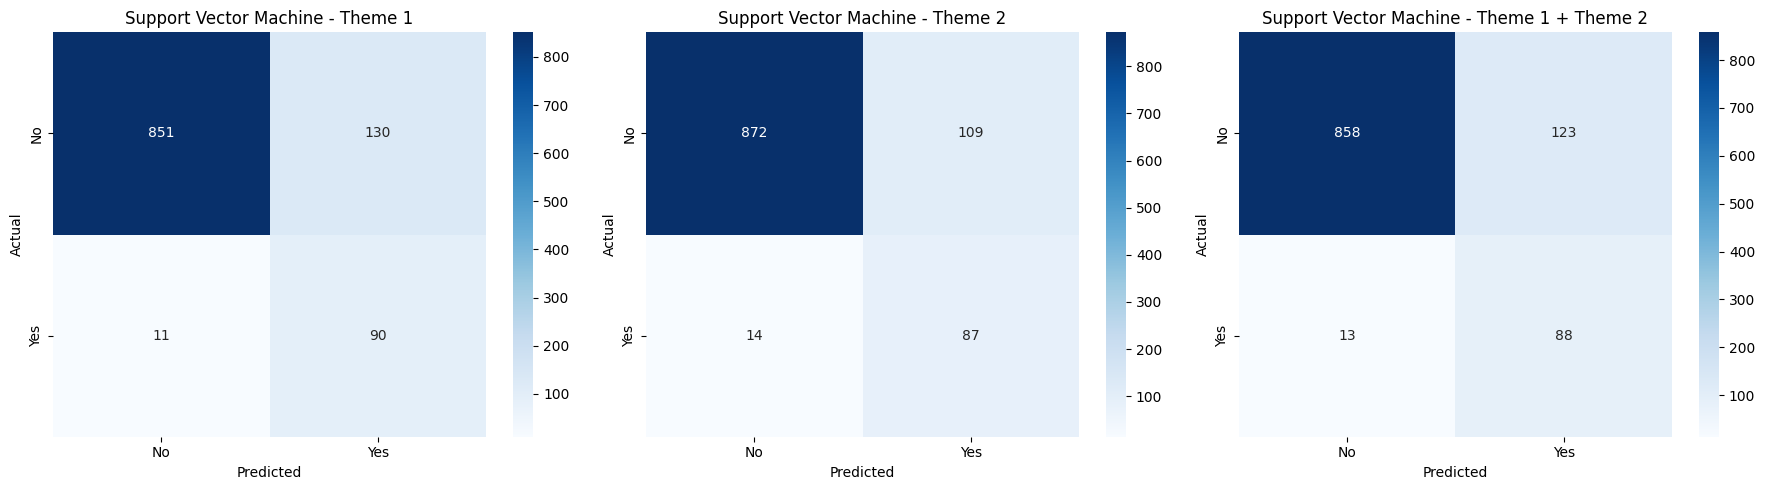

In [65]:
# ============================================
# Support Vector Machine Confusion Matrices
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Theme 1
sns.heatmap(
    confusion_matrix(y1_test, y1_pred_svm, labels=['No', 'Yes']),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes'],
    ax=axes[0]
)

axes[0].set_title('Support Vector Machine - Theme 1')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')


# Theme 2
sns.heatmap(
    confusion_matrix(y2_test, y2_pred_svm, labels=['No', 'Yes']),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes'],
    ax=axes[1]
)

axes[1].set_title('Support Vector Machine - Theme 2')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')


# Theme 1 + Theme 2
sns.heatmap(
    confusion_matrix(y12_test, y12_pred_svm, labels=['No', 'Yes']),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes'],
    ax=axes[2]
)

axes[2].set_title('Support Vector Machine - Theme 1 + Theme 2')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# **Section 13.4 — Artificial Neural Network (ANN)**

In [66]:
# ==================================================
# Section 13.4: Artificial Neural Network
# ==================================================

# Import Artificial Neural Network classifier
from sklearn.neural_network import MLPClassifier

In [67]:
# Create Artificial Neural Network pipeline
ann_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('ann', MLPClassifier(
        random_state=42,
        max_iter=1000
    ))
])

In [68]:
# Define Artificial Neural Network hyperparameters
ann_param_grid = {
    'ann__hidden_layer_sizes': [(32,), (64,), (64, 32)],
    'ann__activation': ['relu', 'tanh'],
    'ann__alpha': [0.0001, 0.001]
}

Artificial Neural Network Theme 1


In [69]:
# --------------------------------------------
# Artificial Neural Network - Theme 1
# --------------------------------------------

ann_grid_theme1 = GridSearchCV(
    estimator=ann_pipeline,
    param_grid=ann_param_grid,
    scoring=f1_scorer,
    cv=cv,
    n_jobs=-1
)

ann_grid_theme1.fit(
    X1_train,
    y1_train
)

print("Theme 1 Best Parameters:")
print(ann_grid_theme1.best_params_)

print("\nTheme 1 Best Cross-Validation F1-Score:")
print(round(ann_grid_theme1.best_score_, 4))

Theme 1 Best Parameters:
{'ann__activation': 'relu', 'ann__alpha': 0.001, 'ann__hidden_layer_sizes': (64,)}

Theme 1 Best Cross-Validation F1-Score:
0.5617


In [70]:
# Get the best Artificial Neural Network model for Theme 1
best_ann_theme1 = ann_grid_theme1.best_estimator_

# Predict the untouched Theme 1 test set
y1_pred_ann = best_ann_theme1.predict(X1_test)

# Get fraud probability for ROC-AUC
y1_prob_ann = best_ann_theme1.predict_proba(X1_test)[:, 1]


# Calculate Artificial Neural Network evaluation metrics - Theme 1
ann1_precision = precision_score(
    y1_test,
    y1_pred_ann,
    pos_label='Yes'
)

ann1_recall = recall_score(
    y1_test,
    y1_pred_ann,
    pos_label='Yes'
)

ann1_f1 = f1_score(
    y1_test,
    y1_pred_ann,
    pos_label='Yes'
)

ann1_accuracy = accuracy_score(
    y1_test,
    y1_pred_ann
)

ann1_roc = roc_auc_score(
    (y1_test == 'Yes').astype(int),
    y1_prob_ann
)

print("Artificial Neural Network - Theme 1")
print("Precision:", round(ann1_precision, 4))
print("Recall:", round(ann1_recall, 4))
print("F1-Score:", round(ann1_f1, 4))
print("Accuracy:", round(ann1_accuracy, 4))
print("ROC-AUC:", round(ann1_roc, 4))

Artificial Neural Network - Theme 1
Precision: 0.4773
Recall: 0.8317
F1-Score: 0.6065
Accuracy: 0.8993
ROC-AUC: 0.9586


Artificial Neural Network Theme 2

In [ ]:
# --------------------------------------------
# Artificial Neural Network - Theme 2
# --------------------------------------------

ann_grid_theme2 = GridSearchCV(
    estimator=ann_pipeline,
    param_grid=ann_param_grid,
    scoring=f1_scorer,
    cv=cv,
    n_jobs=-1
)

ann_grid_theme2.fit(
    X2_train,
    y2_train
)

print("Theme 2 Best Parameters:")
print(ann_grid_theme2.best_params_)

print("\nTheme 2 Best Cross-Validation F1-Score:")
print(round(ann_grid_theme2.best_score_, 4))

In [ ]:
# Get the best Artificial Neural Network model for Theme 2
best_ann_theme2 = ann_grid_theme2.best_estimator_

# Predict the untouched Theme 2 test set
y2_pred_ann = best_ann_theme2.predict(X2_test)

# Get fraud probability for ROC-AUC
y2_prob_ann = best_ann_theme2.predict_proba(X2_test)[:, 1]


# Calculate Artificial Neural Network evaluation metrics - Theme 2
ann2_precision = precision_score(
    y2_test,
    y2_pred_ann,
    pos_label='Yes'
)

ann2_recall = recall_score(
    y2_test,
    y2_pred_ann,
    pos_label='Yes'
)

ann2_f1 = f1_score(
    y2_test,
    y2_pred_ann,
    pos_label='Yes'
)

ann2_accuracy = accuracy_score(
    y2_test,
    y2_pred_ann
)

ann2_roc = roc_auc_score(
    (y2_test == 'Yes').astype(int),
    y2_prob_ann
)

print("Artificial Neural Network - Theme 2")
print("Precision:", round(ann2_precision, 4))
print("Recall:", round(ann2_recall, 4))
print("F1-Score:", round(ann2_f1, 4))
print("Accuracy:", round(ann2_accuracy, 4))
print("ROC-AUC:", round(ann2_roc, 4))

Artificial Neural Network Theme 1 + Theme 2


In [ ]:
# --------------------------------------------
# Artificial Neural Network - Theme 1 + Theme 2
# --------------------------------------------

ann_grid_theme12 = GridSearchCV(
    estimator=ann_pipeline,
    param_grid=ann_param_grid,
    scoring=f1_scorer,
    cv=cv,
    n_jobs=-1
)

ann_grid_theme12.fit(
    X12_train,
    y12_train
)

print("Theme 1 + Theme 2 Best Parameters:")
print(ann_grid_theme12.best_params_)

print("\nTheme 1 + Theme 2 Best Cross-Validation F1-Score:")
print(round(ann_grid_theme12.best_score_, 4))

In [ ]:
# Get the best Artificial Neural Network model for Theme 1 + Theme 2
best_ann_theme12 = ann_grid_theme12.best_estimator_

# Predict the untouched Theme 1 + Theme 2 test set
y12_pred_ann = best_ann_theme12.predict(X12_test)

# Get fraud probability for ROC-AUC
y12_prob_ann = best_ann_theme12.predict_proba(X12_test)[:, 1]


# Calculate Artificial Neural Network evaluation metrics - Theme 1 + Theme 2
ann12_precision = precision_score(
    y12_test,
    y12_pred_ann,
    pos_label='Yes'
)

ann12_recall = recall_score(
    y12_test,
    y12_pred_ann,
    pos_label='Yes'
)

ann12_f1 = f1_score(
    y12_test,
    y12_pred_ann,
    pos_label='Yes'
)

ann12_accuracy = accuracy_score(
    y12_test,
    y12_pred_ann
)

ann12_roc = roc_auc_score(
    (y12_test == 'Yes').astype(int),
    y12_prob_ann
)

print("Artificial Neural Network - Theme 1 + Theme 2")
print("Precision:", round(ann12_precision, 4))
print("Recall:", round(ann12_recall, 4))
print("F1-Score:", round(ann12_f1, 4))
print("Accuracy:", round(ann12_accuracy, 4))
print("ROC-AUC:", round(ann12_roc, 4))

In [ ]:
# ============================================
# Artificial Neural Network Confusion Matrices
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Theme 1
sns.heatmap(
    confusion_matrix(y1_test, y1_pred_ann, labels=['No', 'Yes']),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes'],
    ax=axes[0]
)

axes[0].set_title('Artificial Neural Network - Theme 1')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')


# Theme 2
sns.heatmap(
    confusion_matrix(y2_test, y2_pred_ann, labels=['No', 'Yes']),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes'],
    ax=axes[1]
)

axes[1].set_title('Artificial Neural Network - Theme 2')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')


# Theme 1 + Theme 2
sns.heatmap(
    confusion_matrix(y12_test, y12_pred_ann, labels=['No', 'Yes']),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes'],
    ax=axes[2]
)

axes[2].set_title('Artificial Neural Network - Theme 1 + Theme 2')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# **14: ROC Curve Model Comparison**

In [ ]:
# ============================================
# Section 14: ROC Curve Model Comparison
# ============================================

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

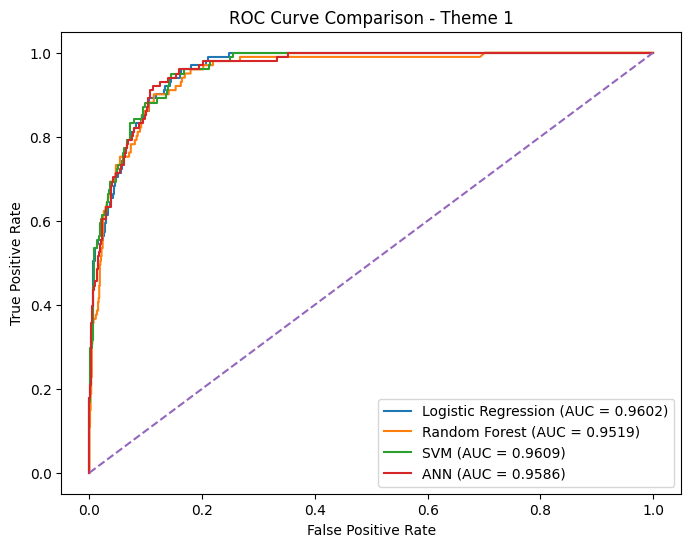

In [82]:
# --------------------------------------------
# ROC Curve Comparison - Theme 1
# --------------------------------------------

# Convert actual fraud labels to 0 and 1
y1_test_binary = (y1_test == 'Yes').astype(int)

# Calculate ROC curves
fpr_lr1, tpr_lr1, _ = roc_curve(y1_test_binary, y1_prob_lr)
fpr_rf1, tpr_rf1, _ = roc_curve(y1_test_binary, y1_prob_rf)
fpr_svm1, tpr_svm1, _ = roc_curve(y1_test_binary, y1_prob_svm)
fpr_ann1, tpr_ann1, _ = roc_curve(y1_test_binary, y1_prob_ann)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(fpr_lr1, tpr_lr1, label='Logistic Regression (AUC = 0.9602)')
plt.plot(fpr_rf1, tpr_rf1, label='Random Forest (AUC = 0.9519)')
plt.plot(fpr_svm1, tpr_svm1, label='SVM (AUC = 0.9609)')
plt.plot(fpr_ann1, tpr_ann1, label='ANN (AUC = 0.9586)')

# Random classifier reference line
plt.plot([0, 1], [0, 1], '--')

plt.title('ROC Curve Comparison - Theme 1')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

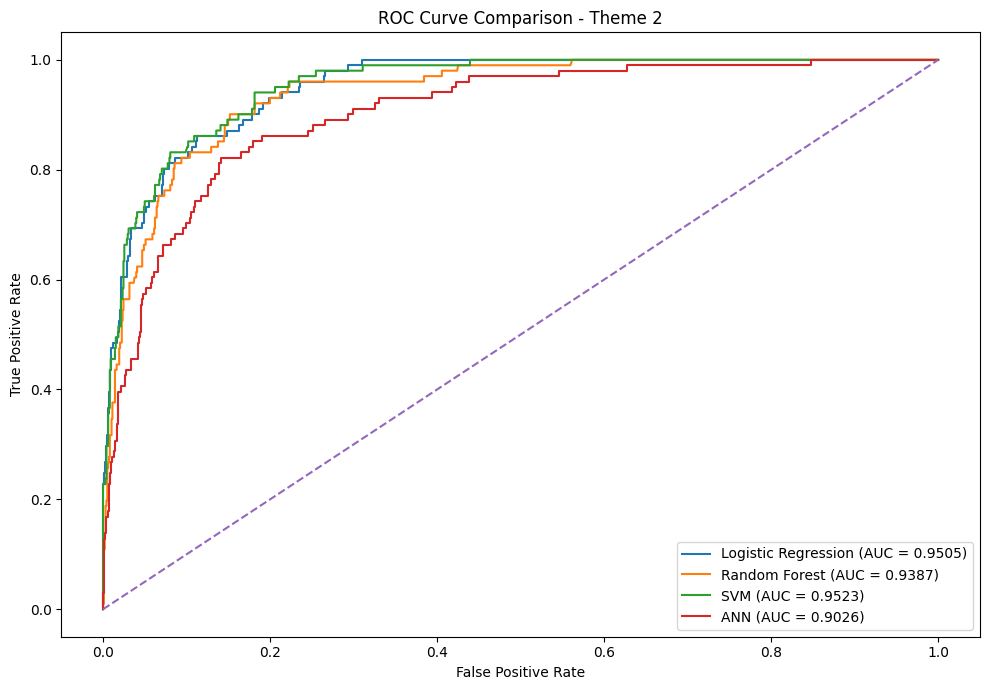

In [81]:
# ============================================
# ROC Curve Comparison - Theme 2
# ============================================

from sklearn.metrics import roc_curve

# Convert actual fraud labels to 0 and 1
y2_test_binary = (y2_test == 'Yes').astype(int)

# Logistic Regression
fpr_lr2, tpr_lr2, _ = roc_curve(y2_test_binary, y2_prob_lr)

# Random Forest
fpr_rf2, tpr_rf2, _ = roc_curve(y2_test_binary, y2_prob_rf)

# Support Vector Machine
fpr_svm2, tpr_svm2, _ = roc_curve(y2_test_binary, y2_prob_svm)

# Artificial Neural Network
fpr_ann2, tpr_ann2, _ = roc_curve(y2_test_binary, y2_prob_ann)


# Plot ROC Curves
plt.figure(figsize=(10, 7))

plt.plot(fpr_lr2, tpr_lr2,
         label=f'Logistic Regression (AUC = {lr2_roc:.4f})')

plt.plot(fpr_rf2, tpr_rf2,
         label=f'Random Forest (AUC = {rf2_roc:.4f})')

plt.plot(fpr_svm2, tpr_svm2,
         label=f'SVM (AUC = {svm2_roc:.4f})')

plt.plot(fpr_ann2, tpr_ann2,
         label=f'ANN (AUC = {ann2_roc:.4f})')

# Random classifier reference line
plt.plot([0, 1], [0, 1], '--')

plt.title('ROC Curve Comparison - Theme 2')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.show()

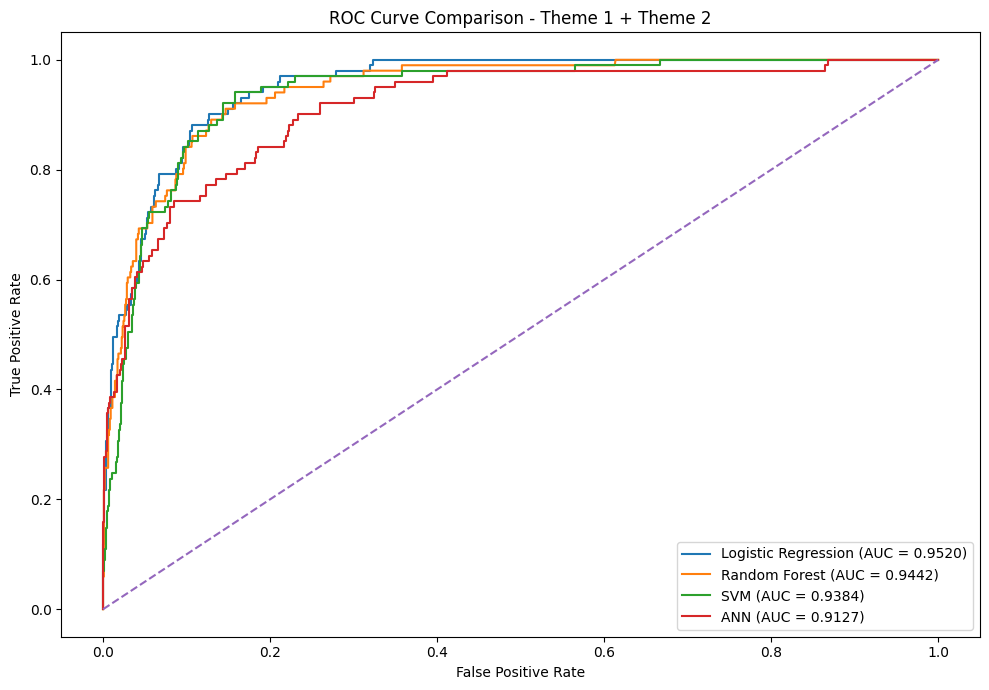

In [80]:
# ============================================
# ROC Curve Comparison - Theme 1 + Theme 2
# ============================================

# Convert actual fraud labels to 0 and 1
y12_test_binary = (y12_test == 'Yes').astype(int)

# Logistic Regression
fpr_lr12, tpr_lr12, _ = roc_curve(y12_test_binary, y12_prob_lr)

# Random Forest
fpr_rf12, tpr_rf12, _ = roc_curve(y12_test_binary, y12_prob_rf)

# Support Vector Machine
fpr_svm12, tpr_svm12, _ = roc_curve(y12_test_binary, y12_prob_svm)

# Artificial Neural Network
fpr_ann12, tpr_ann12, _ = roc_curve(y12_test_binary, y12_prob_ann)


# Plot ROC Curves
plt.figure(figsize=(10, 7))

plt.plot(fpr_lr12, tpr_lr12,
         label=f'Logistic Regression (AUC = {lr12_roc:.4f})')

plt.plot(fpr_rf12, tpr_rf12,
         label=f'Random Forest (AUC = {rf12_roc:.4f})')

plt.plot(fpr_svm12, tpr_svm12,
         label=f'SVM (AUC = {svm12_roc:.4f})')

plt.plot(fpr_ann12, tpr_ann12,
         label=f'ANN (AUC = {ann12_roc:.4f})')

# Random classifier reference line
plt.plot([0, 1], [0, 1], '--')

plt.title('ROC Curve Comparison - Theme 1 + Theme 2')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.show()

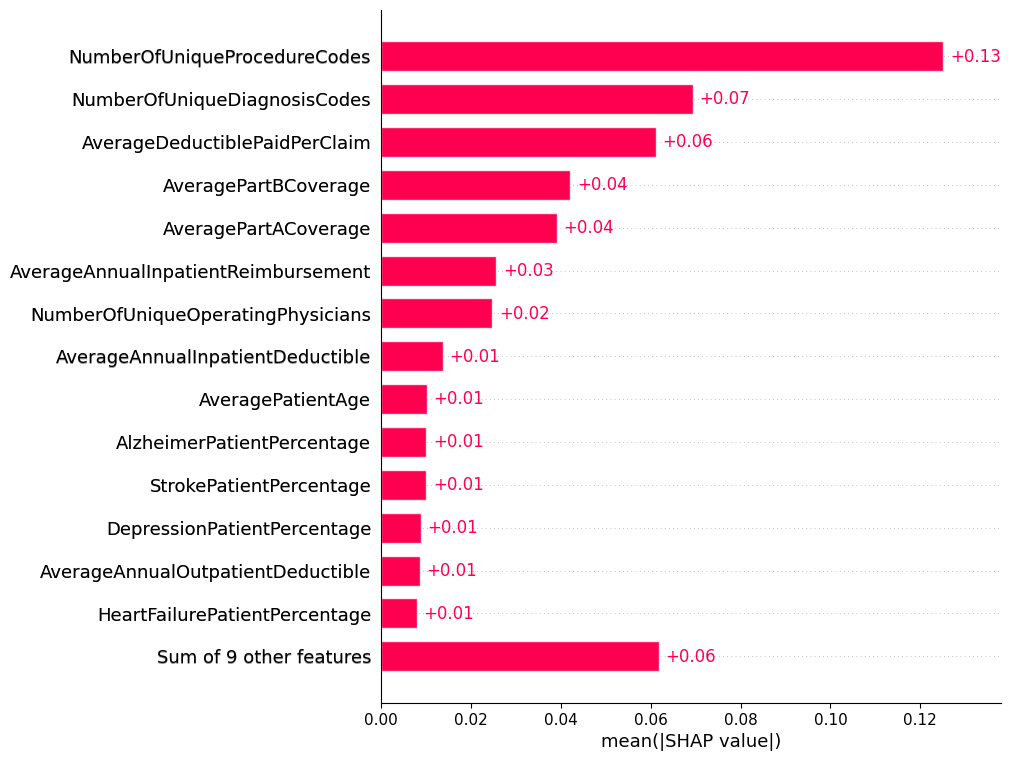

In [83]:
# Import SHAP and explain the Random Forest Theme 2 model.

import shap

# Extract the trained Random Forest model from the pipeline.
rf_theme2_model = best_rf_theme2.named_steps['random_forest']

# Calculate SHAP values using the Theme 2 test data.
explainer_rf_theme2 = shap.TreeExplainer(rf_theme2_model)
shap_values_rf_theme2 = explainer_rf_theme2(X2_test)

# Display SHAP feature importance for the fraud class.
shap.plots.bar(shap_values_rf_theme2[:, :, 1], max_display=15)